In [1]:
#%%time
import os
import re
import gzip
import math
import random
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import anndata as ad

from ast import literal_eval
import warnings
# 忽略 FutureWarning 类型警告
warnings.simplefilter(action='ignore', category=FutureWarning)
# 忽略特定类型的警告：忽略 scanpy包中含有 ignore 的 UserWarning 类型警告
warnings.filterwarnings("ignore", category=UserWarning, module="scanpy")
# 禁用 pandas 包中的 SettingWithCopyWarning 类型警告  
pd.options.mode.chained_assignment = None  # 或 'raise' 表示引发异常

import inferECC
from inferECC import *

species value: hg38
species == 'mm10':  False


In [2]:
def get_all_folders(path):
    folders = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]
    return folders
"""
# 指定路径
target_path = library_dir # '/your/target/directory' 
# 获取所有文件夹
folders_list = get_all_folders(target_path)
"""

"\n# 指定路径\ntarget_path = library_dir # '/your/target/directory'\n# 获取所有文件夹\nfolders_list = get_all_folders(target_path)\n"

In [165]:
os.chdir("D:/02.project/18.ecDNA/02.code/v0.1.1/")
print(os.getcwd())

D:\02.project\18.ecDNA\02.code\v0.1.1


In [4]:
### cancer in common & cell ratio in sample/cancer

In [5]:
import pandas as pd
import numpy as np

def get_df_nozero_median(df=pd.DataFrame()):
    # 假设df是你的DataFrame
    df = df.copy()
    # 获取df中的所有元素，组成一个list a
    a = df.values.flatten().tolist()
    # 去掉list a中所有的值为0的元素
    a = [i for i in a if i != 0]
    # 获取list a的中位数值
    median = np.median(a)
    return median
    
def get_df_nozero_quartile(df=pd.DataFrame(), percent=75):
    # 假设df是你的DataFrame
    df = df.copy()
    # 获取df中的所有元素，组成一个list a
    a = df.values.flatten().tolist()
    # 去掉list a中所有的值为0的元素
    a = [i for i in a if i != 0]
    # 获取list a的四分之三位数值
    quartile_3 = np.percentile(a, percent)
    return quartile_3

#get_df_nozaro_median(df_filled2)

In [181]:
df_filled = pd.read_csv(f'./fig_100k/cell_ratio/t01-cancer_sample_ecdna-in-cell_ratio.tsv',sep="\t",index_col=0,header=[0,1,2])
# 删除 level2\3 索引
df_filled.columns = df_filled.columns.droplevel([1,2])

df_filled2 = pd.read_csv(f'./fig_100k/cell_ratio/t02-cancer_ecdna-in-cell_ratio.tsv',sep="\t",index_col=0,header=[0,1])
# 删除 level2 索引
df_filled2.columns = df_filled2.columns.droplevel([1])

In [182]:
cancer_ecdna = pd.read_csv("./fig_100k/upsetplot/f04-upsetplot_pan-cancer_all_ecdna.tsv",sep="\t",index_col=0)
cancer_ecdna

,BRCA,CEAD,CESC,CRC,HNSCC,MM,OV,PDAC,SKCM,UCEC,row_sum
chr1:5700000_5800000,1,0,0,0,1,0,1,1,1,1,6
chr15:50100000_50200000,1,0,0,0,0,0,0,0,0,0,1
chr4:69700000_69800000,0,0,0,0,0,0,0,1,0,0,1
chr2:176700000_176800000,1,0,0,0,0,0,0,0,0,0,1
chr2:55200000_55300000,1,0,1,1,1,0,1,1,1,1,8
...,...,...,...,...,...,...,...,...,...,...,...
chrX:138700000_138800000,1,0,0,0,0,0,0,0,0,0,1
chr2:2900000_3000000,0,0,0,0,0,0,0,0,0,1,1
chr7:74500000_74600000,1,1,1,1,1,0,1,1,1,1,9
chr19:18200000_18300000,1,1,1,1,1,1,1,1,1,1,10


In [183]:
# common specific ecdna
#  N_cancers
cancer_ecdna_common1 = cancer_ecdna[cancer_ecdna["row_sum"]==1]
cancer_ecdna_common9 = cancer_ecdna[cancer_ecdna["row_sum"]==9]
cancer_ecdna_common10 = cancer_ecdna[cancer_ecdna["row_sum"]==10]

cancer_ecdna_common_m = cancer_ecdna[(cancer_ecdna["row_sum"]==1)|(cancer_ecdna["row_sum"]==10)|(cancer_ecdna["row_sum"]==9)]
print(len(cancer_ecdna_common_m))

cancer_ecdna_common1.sort_values(by=cancer_ecdna_common1.columns.to_list(), ascending=False, inplace=True)
cancer_ecdna_common9.sort_values(by=cancer_ecdna_common9.columns.to_list(), ascending=True, inplace=True)
cancer_ecdna_common10.sort_values(by=cancer_ecdna_common10.columns.to_list(), ascending=False, inplace=True)

8560


In [184]:
def find_0_columns(row):
    return row.index[row.eq(0)].tolist()[0]+"_specific_negative"

def find_1_columns(row):
    return row.index[row.eq(1)].tolist()[0]+"_specific_positive"
    
cancer_ecdna_common9["label"] = cancer_ecdna_common9.apply(find_0_columns, axis=1)
cancer_ecdna_common1["label"] = cancer_ecdna_common1.apply(find_1_columns, axis=1)
cancer_ecdna_common9["label_abbr"] = "specific_negative"
cancer_ecdna_common1["label_abbr"] = "specific_positive"
cancer_ecdna_common10["label"] = "common"
cancer_ecdna_common10["label_abbr"] = "common"

cancer_ecdna_common_merge = pd.concat([cancer_ecdna_common1, cancer_ecdna_common10, cancer_ecdna_common9], axis=0)
cancer_ecdna_common_merge

,BRCA,CEAD,CESC,CRC,HNSCC,MM,OV,PDAC,SKCM,UCEC,row_sum,label,label_abbr
chr15:50100000_50200000,1,0,0,0,0,0,0,0,0,0,1,BRCA_specific_positive,specific_positive
chr2:176700000_176800000,1,0,0,0,0,0,0,0,0,0,1,BRCA_specific_positive,specific_positive
chr4:169400000_169500000,1,0,0,0,0,0,0,0,0,0,1,BRCA_specific_positive,specific_positive
chr10:81000000_81100000,1,0,0,0,0,0,0,0,0,0,1,BRCA_specific_positive,specific_positive
chr4:98800000_98900000,1,0,0,0,0,0,0,0,0,0,1,BRCA_specific_positive,specific_positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...
chr2:230600000_230700000,1,1,1,1,1,1,1,1,0,1,9,SKCM_specific_negative,specific_negative
chr5:32200000_32300000,1,1,1,1,1,1,1,1,0,1,9,SKCM_specific_negative,specific_negative
chr5:168300000_168400000,1,1,1,1,1,1,1,1,0,1,9,SKCM_specific_negative,specific_negative
chr15:57500000_57600000,1,1,1,1,1,1,1,1,0,1,9,SKCM_specific_negative,specific_negative


In [185]:
# 根据行名进行筛选  by-cancer
df_filled_ecdna_common = df_filled2.loc[cancer_ecdna_common_merge.index]
df_filled_ecdna_common

,BRCA,CEAD,CESC,CRC,HNSCC,MM,OV,PDAC,SKCM,UCEC
chr15:50100000_50200000,0.000655,0.000000,0.000081,0.000105,0.000000,0.001417,0.000096,0.000050,0.000000,0.000198
chr2:176700000_176800000,0.000411,0.000000,0.000000,0.000000,0.000000,0.003011,0.000096,0.000000,0.000235,0.000273
chr4:169400000_169500000,0.000225,0.000000,0.000000,0.000000,0.000000,0.002657,0.000096,0.000050,0.000000,0.000000
chr10:81000000_81100000,0.000166,0.000000,0.000000,0.000000,0.000000,0.001240,0.000000,0.000000,0.000000,0.000074
chr4:98800000_98900000,0.000166,0.000000,0.000000,0.000000,0.000073,0.001240,0.000000,0.000000,0.000000,0.000099
...,...,...,...,...,...,...,...,...,...,...
chr2:230600000_230700000,0.000665,0.001181,0.002156,0.001001,0.000930,0.003542,0.001220,0.001260,0.000164,0.001588
chr5:32200000_32300000,0.022302,0.010455,0.000447,0.000806,0.000269,0.003542,0.002408,0.000862,0.000188,0.003474
chr5:168300000_168400000,0.003549,0.002126,0.001627,0.000672,0.000955,0.006199,0.010531,0.002338,0.000000,0.003250
chr15:57500000_57600000,0.004400,0.001004,0.001119,0.003136,0.000245,0.004605,0.002665,0.003516,0.000188,0.003722


In [186]:
mask = cancer_ecdna_common_merge.iloc[:,:10]
df_filled_ecdna_common_after_mask = df_filled_ecdna_common*mask
df_filled_ecdna_common_after_mask["label"] = cancer_ecdna_common_merge["label"]
df_filled_ecdna_common_after_mask["label_abbr"] = cancer_ecdna_common_merge["label_abbr"]
#df_filled_ecdna_common_after_mask.to_csv('./fig_100k/cell_ratio/common/f09-ecdna_cancer_common-cell_ratio_clustermap_by-sample_xy_common-specific_all-ecdna.tsv', sep="\t",index=True)
df_filled_ecdna_common_after_mask

,BRCA,CEAD,CESC,CRC,HNSCC,MM,OV,PDAC,SKCM,UCEC,label,label_abbr
chr15:50100000_50200000,0.000655,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,BRCA_specific_positive,specific_positive
chr2:176700000_176800000,0.000411,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,BRCA_specific_positive,specific_positive
chr4:169400000_169500000,0.000225,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,BRCA_specific_positive,specific_positive
chr10:81000000_81100000,0.000166,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,BRCA_specific_positive,specific_positive
chr4:98800000_98900000,0.000166,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,BRCA_specific_positive,specific_positive
...,...,...,...,...,...,...,...,...,...,...,...,...
chr2:230600000_230700000,0.000665,0.001181,0.002156,0.001001,0.000930,0.003542,0.001220,0.001260,0.000000,0.001588,SKCM_specific_negative,specific_negative
chr5:32200000_32300000,0.022302,0.010455,0.000447,0.000806,0.000269,0.003542,0.002408,0.000862,0.000000,0.003474,SKCM_specific_negative,specific_negative
chr5:168300000_168400000,0.003549,0.002126,0.001627,0.000672,0.000955,0.006199,0.010531,0.002338,0.000000,0.003250,SKCM_specific_negative,specific_negative
chr15:57500000_57600000,0.004400,0.001004,0.001119,0.003136,0.000245,0.004605,0.002665,0.003516,0.000000,0.003722,SKCM_specific_negative,specific_negative


In [187]:
def top10_by_mean(df):
    # 计算每行前10个元素的均值
    df['mean'] = df.iloc[:, :10].mean(axis=1)
    # 保留均值最大的top10行
    return df.nlargest(10, 'mean')

df_top10 = df_filled_ecdna_common_after_mask.groupby("label").apply(top10_by_mean)
df_top10.index = df_top10.index.droplevel("label")
label_list = list(cancer_ecdna_common_merge["label"].unique())
# 将"label"列转换为Categorical类型，并指定类别的顺序
df_top10['label'] = pd.Categorical(df_top10['label'], categories=label_list, ordered=True)
df_top10
# 根据"label"列进行排序
df_top10_sorted = df_top10.sort_values(by='label')
# 将行索引名称改为"ecDNA_CPR"
df_top10_sorted.rename_axis("ecDNA_CPR", axis=0, inplace=True)
df_top10_sorted.rename_axis("cancer", axis=1, inplace=True)
# 将"label"列设置为新的一级索引
df_top10_sorted.set_index('label', append=True, inplace=True)
df_top10_sorted.set_index('label_abbr', append=True, inplace=True)
# 删除"label"列和"dede"列
df_top10_sorted.drop(columns=['mean'], inplace=True)

## 值取对数处理
df_top10_sorted = np.log(df_top10_sorted)*0.1+1
# 将df中的负无穷值替换为 0
df_top10_sorted.replace(-np.inf, 0, inplace=True)
#df_top10_sorted.to_csv('./fig_100k/cell_ratio/common/f09-ecdna_cancer_common-cell_ratio_clustermap_by-sample_xy_common-specific.tsv',sep="\t",index=True)
df_top10_sorted

C:\Users\wangyuhang\.conda\envs\py310\lib\site-packages\pandas\core\internals\blocks.py:351: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)


,,cancer,BRCA,CEAD,CESC,CRC,HNSCC,MM,OV,PDAC,SKCM,UCEC
ecDNA_CPR,label,label_abbr,,,,,,,,,,
chr18:25300000_25400000,BRCA_specific_positive,specific_positive,0.536428,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
chr12:3800000_3900000,BRCA_specific_positive,specific_positive,0.535517,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
chr8:116900000_117000000,BRCA_specific_positive,specific_positive,0.448801,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
chr18:25500000_25600000,BRCA_specific_positive,specific_positive,0.447583,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
chr8:115900000_116000000,BRCA_specific_positive,specific_positive,0.428761,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
chr1:54800000_54900000,SKCM_specific_negative,specific_negative,0.467315,0.402436,0.489736,0.342073,0.371319,0.449679,0.486305,0.429128,0.00000,0.438620
chr10:24400000_24500000,SKCM_specific_negative,specific_negative,0.465692,0.428851,0.360364,0.353253,0.394681,0.449679,0.411947,0.387576,0.00000,0.462688
chr5:32200000_32300000,SKCM_specific_negative,specific_negative,0.619693,0.543931,0.228796,0.287712,0.178036,0.435703,0.397105,0.294421,0.00000,0.433741


<Figure size 800x800 with 0 Axes>

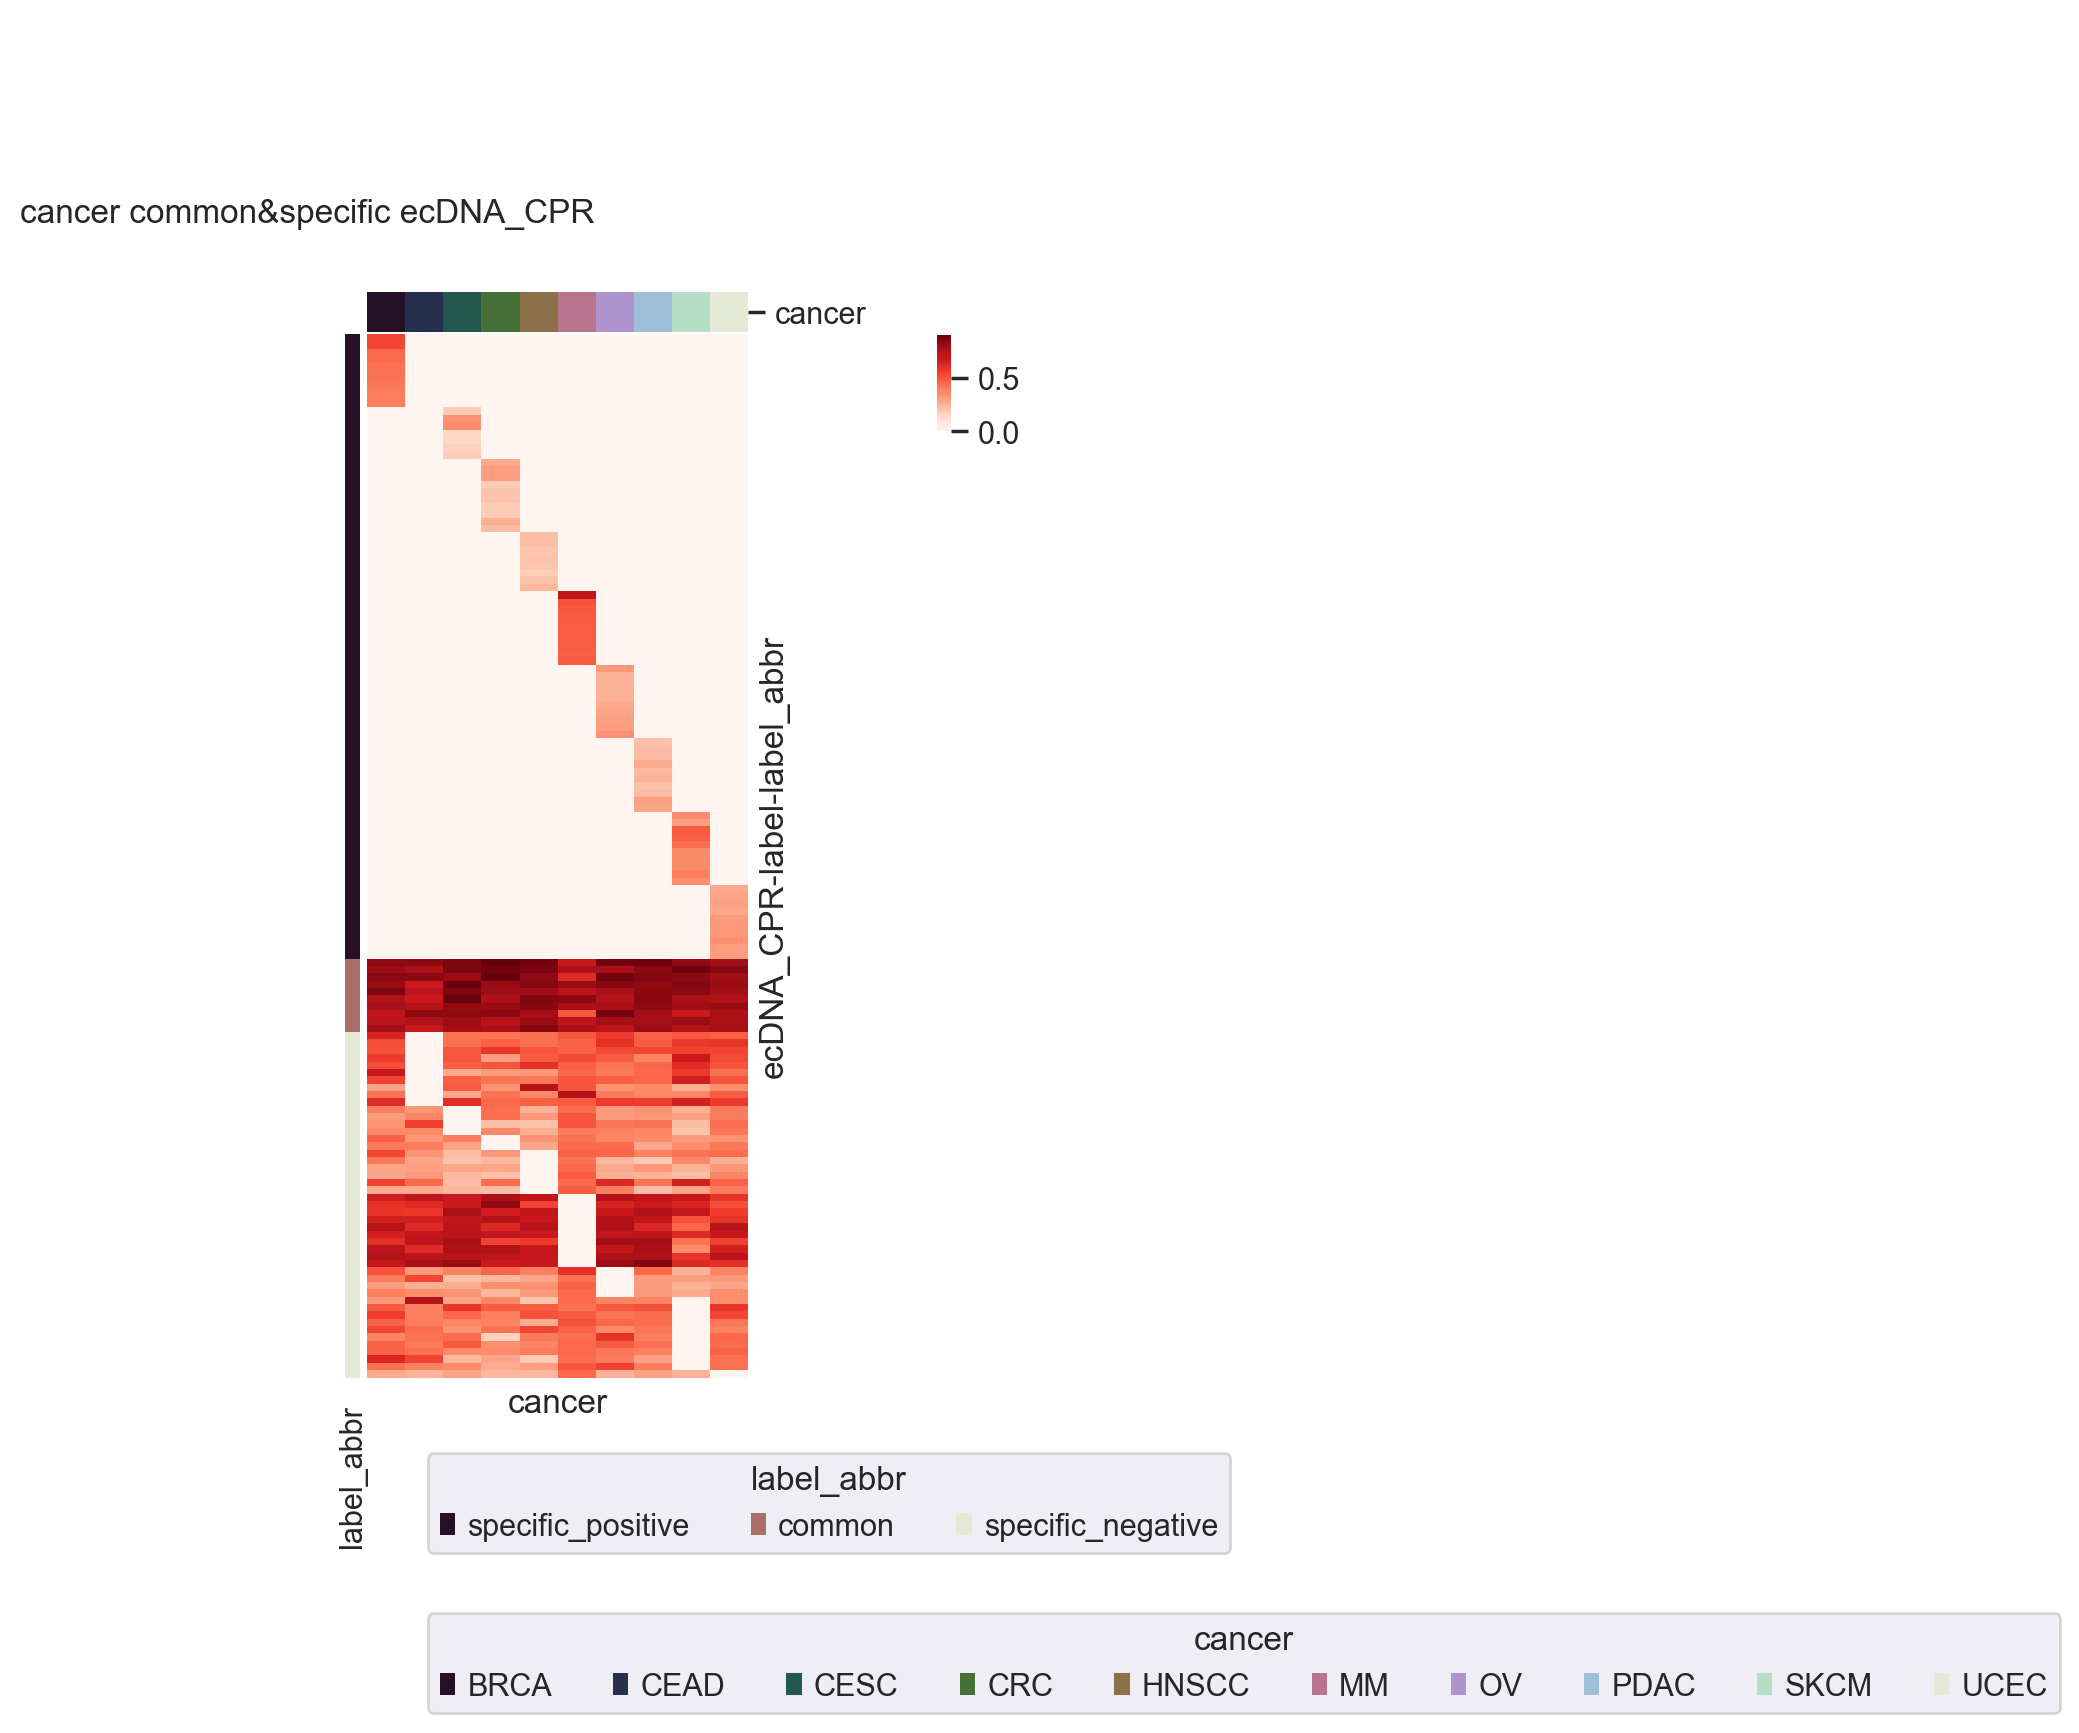

In [201]:
# 创建颜色映射
cancer_labels = df_top10_sorted.columns
cancer_pal = sns.cubehelix_palette(cancer_labels.unique().size, light=.9, dark=.1, reverse=True, start=1, rot=-2)
cancer_lut = dict(zip(map(str, cancer_labels.unique()), cancer_pal))
cancer_colors = pd.Series(cancer_labels, index=df_top10_sorted.columns).map(cancer_lut)

label_abbr_labels = df_top10_sorted.index.get_level_values("label_abbr")
label_abbr_pal = sns.cubehelix_palette(label_abbr_labels.unique().size, light=.9, dark=.1, reverse=True, start=1, rot=-2)
label_abbr_lut = dict(zip(map(str, label_abbr_labels.unique()), label_abbr_pal))
label_abbr_colors = pd.Series(label_abbr_labels, index=df_top10_sorted.index).map(label_abbr_lut)

plt.figure(dpi=200)
# 创建clustermap
g = sns.clustermap(df_top10_sorted, 
                   #method='ward', #"average","single","complete","weighted","centroid","median","ward",
                   row_cluster=False, 
                   col_cluster=False, 
                   row_colors=label_abbr_colors, 
                   col_colors=cancer_colors, 
                   linewidths=0,
                   figsize=(3.5, 8),
                   cmap='Reds',#"vlag"\"Reds"
                   xticklabels=False, yticklabels=False)
from matplotlib.pyplot import gcf
for label in cancer_labels.unique():
    g.ax_col_dendrogram.bar(0, 0, color=cancer_lut[label], label=label, linewidth=0)
l1 = g.ax_col_dendrogram.legend(title='cancer', 
                                loc="center left", 
                                ncol=10, bbox_to_anchor=(0.3, -0.05),
                                bbox_transform=gcf().transFigure)
for label in label_abbr_labels.unique():
    g.ax_row_dendrogram.bar(0, 0, color=label_abbr_lut[label], label=label, linewidth=0)
l2 = g.ax_row_dendrogram.legend(title='label_abbr', 
                                loc="center left", 
                                ncol=3, bbox_to_anchor=(0.3, 0.05),
                                bbox_transform=gcf().transFigure)

g.cax.set_position([1.05, 0.72, .02, .06]) # 调整颜色条的位置
#plt.show()
plt.title(f'cancer common&specific ecDNA_CPR',x=-45, y=2)
plt.savefig("./fig_100k/cell_ratio/common/f09-ecdna_cancer_common-cell_ratio_clustermap_by-sample_xy_common-specific_3.pdf", bbox_inches='tight')

In [245]:
### anno ecdna2gene

In [280]:
df_top10_sorted = pd.read_csv('./fig_100k/cell_ratio/common/f09-ecdna_cancer_common-cell_ratio_clustermap_by-sample_xy_common-specific.tsv',
                              sep="\t",index_col=[0,1,2],header=0)
df_filled_ecdna_common_after_mask = pd.read_csv('./fig_100k/cell_ratio/common/f09-ecdna_cancer_common-cell_ratio_clustermap_by-sample_xy_common-specific_all-ecdna.tsv',
                                                sep="\t",index_col=[0],header=[0])

common_ecdna = pd.read_csv('./fig_100k/cell_ratio/common/f09-ecdna_cancer_common-cell_ratio_clustermap_by-sample_xy_tree.tsv',
                           sep="\t",index_col=[0],header=[0])
common_ecdna

,links_color_list,leaves,leaves_label,leaves_color_list,raw_leaves_label,ecdna_type
0,y,593,593,y,chr17:43500000_43600000,low-frequency_non-uniform
1,y,1127,1127,y,chr17:48600000_48700000,low-frequency_non-uniform
2,y,1538,1538,y,chr16:70400000_70500000,low-frequency_non-uniform
3,y,1629,1629,y,chr2:47300000_47400000,low-frequency_non-uniform
4,y,515,515,y,chr12:12700000_12800000,low-frequency_non-uniform
...,...,...,...,...,...,...
1734,m,103,103,m,chr6:32900000_33000000,high-frequency_non-uniform
1735,m,1730,1730,m,chr6:32800000_32900000,high-frequency_non-uniform
1736,#bcbddc,1612,1612,m,chr6:26100000_26200000,high-frequency_non-uniform
1737,#bcbddc,547,547,m,chr6:27800000_27900000,high-frequency_non-uniform


In [281]:
import warnings
import scanpy as sc
from ast import literal_eval

cancer_gene_tb = pd.read_csv("D:\\02.project\\18.ecDNA\\02.method\\ref\\hg19\\cancer_gene_census_20240307.txt",sep="\t")
cancer_gene_list = list(cancer_gene_tb["Gene Symbol"].unique())

# DataFrame :: gene_unique_list 是  match oncogene 的列list元素
def custom_transform(element):
    if isinstance(element, list):
        # 提取元素列表与 oncogene_list 的交集
        return list(set(element) & set(cancer_gene_list))
    else:
        # 如果元素是 NaN，则返回 NaN
        return element

# 将自定义函数 custom_transform 应用到 gene_unique_list 列
#df['oncogene'] = df['gene_unique_list'].apply(custom_transform)

In [282]:
df_top10_sorted["chr_raw"] = df_top10_sorted.index.get_level_values("ecDNA_CPR")
df_ecdna = df_top10_sorted.copy()
df_ecdna_gene = genebody_region(df_fragments=df_ecdna,species="hg38")
df_ecdna_gene['oncogene'] = df_ecdna_gene['genebody_region_gene'].apply(custom_transform)
#df_ecdna_gene.to_csv("./fig_100k/df_ecdna_gene_oncogene.tsv",sep="\t",index=True)

species value: hg38


In [291]:
### specific ecdna gene oncogene

df_filled_ecdna_common_after_mask["chr_raw"] = df_filled_ecdna_common_after_mask.index
df_ecdna = df_filled_ecdna_common_after_mask.copy()
df_ecdna_gene = genebody_region(df_fragments=df_ecdna,species="hg38")
df_ecdna_gene['oncogene'] = df_ecdna_gene['genebody_region_gene'].apply(custom_transform)
#df_ecdna_gene.to_csv("./fig_100k/df_ecdna_gene_oncogene_all-ecdna.tsv",sep="\t",index=True)

# 定义一个函数来处理 oncogene 列的元素：：转变oncogene_nor 元素0值为[]
def process_gene_list(item):
    # 如果元素是整数0，返回一个空列表
    if item == 0:
        return []
    # 否则，返回原始的元素
    else:
        return item
# 使用 apply 函数
df_ecdna_gene['oncogene_nor'] = df_ecdna_gene['oncogene'].apply(process_gene_list)

# 定义一个函数来处理 oncogene_nor 列的元素::合并oncogene_nor list
def process_gene_list(gene_list):
    # 创建一个空列表来存储结果
    result = []
    for item in gene_list:
        # 如果元素是列表，将它的元素添加到结果中
        if isinstance(item, list):
            result.extend(item)
    return result
# 使用 groupby 和 apply 函数:: specific/common：：label/ecdna_type
df_ecdna_gene_grouped = df_ecdna_gene.groupby('label')['oncogene_nor'].apply(process_gene_list).reset_index() # specific 
#df_ecdna_gene_grouped = df_ecdna_gene.groupby('ecdna_type')['oncogene_nor'].apply(process_gene_list).reset_index() # common

# 将 label 列转换为 Categorical 类型，并指定类别的顺序
df_ecdna_gene_grouped['label'] = pd.Categorical(df_ecdna_gene_grouped['label'], 
                                                categories=list(df_ecdna_gene['label'].unique()), 
                                                ordered=True)
# 使用 sort_values 函数进行排序
df_ecdna_gene_grouped = df_ecdna_gene_grouped.sort_values('label')

import pandas as pd
from collections import Counter
# 定义一个函数来处理 oncogene_nor 列的元素
def process_oncogene_nor(oncogene_nor):
    # 使用 Counter 对元素进行频数统计
    counter = Counter(oncogene_nor)
    # 提取频数最高的5个元素
    most_common = counter.most_common(15) # 6/15
    # 将这5个元素组成一个列表
    result = [item[0] for item in most_common]
    return result
# 使用 apply 函数
df_ecdna_gene_grouped['most_common_oncogenes'] = df_ecdna_gene_grouped['oncogene_nor'].apply(process_oncogene_nor)
df_ecdna_gene_grouped.to_csv("./fig_100k/df_ecdna_gene_oncogene_all-ecdna_gene_oncogene-unique.tsv",
                     sep="\t",index=True)
df_ecdna_gene_grouped

species value: hg38


,label,oncogene_nor,most_common_oncogenes
0,BRCA_specific_positive,"[CREB3L2, KDM6A, TCF12, SSX1, GPC3, ATM, AKT3,...","[ERBB4, LRP1B, ROBO2, FHIT, PTPRT, CTNND2, CNT..."
3,CESC_specific_positive,[SOX21],[SOX21]
5,CRC_specific_positive,[],[]
7,HNSCC_specific_positive,[MECOM],[MECOM]
9,MM_specific_positive,"[ROBO2, GRIN2A, DCC, GRIN2A, BRIP1, ZNF479, FHIT]","[GRIN2A, ROBO2, DCC, BRIP1, ZNF479, FHIT]"
11,OV_specific_positive,[],[]
12,PDAC_specific_positive,"[FAS, VTI1A]","[FAS, VTI1A]"
14,SKCM_specific_positive,"[MITF, PAX3, ROBO2, FCGR2B, RB1]","[MITF, PAX3, ROBO2, FCGR2B, RB1]"
16,UCEC_specific_positive,"[CTNNA2, RGS7, MECOM, CNBD1, CTNNA2, RGS7, EBF...","[CTNNA2, RGS7, EBF1, MECOM, CNBD1, CTNND2, GNA..."
17,common,"[COL2A1, FEN1, SMARCB1, MEN1, NCOR2, CBFB, GLI...","[NCOR2, PRDM16, SMARCB1, SMARCD1, CHD4, KEAP1,..."


In [ ]:
### comomon ecdna gene oncogene

In [288]:
common_ecdna["chr_raw"] = common_ecdna["raw_leaves_label"]
df_ecdna = common_ecdna.copy()
df_ecdna_gene = genebody_region(df_fragments=df_ecdna,species="hg38")
df_ecdna_gene['oncogene'] = df_ecdna_gene['genebody_region_gene'].apply(custom_transform)
df_ecdna_gene.to_csv("./fig_100k/cell_ratio/common/f09-ecdna_cancer_common-cell_ratio_clustermap_by-sample_xy_tree_gene_oncogene.tsv",
                     sep="\t",index=True)

# 定义一个函数来处理 oncogene 列的元素：：转变oncogene_nor 元素0值为[]
def process_gene_list(item):
    # 如果元素是整数0，返回一个空列表
    if item == 0:
        return []
    # 否则，返回原始的元素
    else:
        return item
# 使用 apply 函数
df_ecdna_gene['oncogene_nor'] = df_ecdna_gene['oncogene'].apply(process_gene_list)

# 定义一个函数来处理 oncogene_nor 列的元素::合并oncogene_nor list
def process_gene_list(gene_list):
    # 创建一个空列表来存储结果
    result = []
    for item in gene_list:
        # 如果元素是列表，将它的元素添加到结果中
        if isinstance(item, list):
            result.extend(item)
    return result
# 使用 groupby 和 apply 函数::label/ecdna_type
#df_ecdna_gene_grouped = df_ecdna_gene.groupby('label')['oncogene_nor'].apply(process_gene_list).reset_index()
df_ecdna_gene_grouped = df_ecdna_gene.groupby('ecdna_type')['oncogene_nor'].apply(process_gene_list).reset_index()

# 将 label 列转换为 Categorical 类型，并指定类别的顺序
df_ecdna_gene_grouped['ecdna_type'] = pd.Categorical(df_ecdna_gene_grouped['ecdna_type'], 
                                                categories=list(df_ecdna_gene['ecdna_type'].unique()), 
                                                ordered=True)
# 使用 sort_values 函数进行排序
df_ecdna_gene_grouped = df_ecdna_gene_grouped.sort_values('ecdna_type')

import pandas as pd
from collections import Counter
# 定义一个函数来处理 oncogene_nor 列的元素
def process_oncogene_nor(oncogene_nor):
    # 使用 Counter 对元素进行频数统计
    counter = Counter(oncogene_nor)
    # 提取频数最高的5个元素
    most_common = counter.most_common(15) # 6/15
    # 将这5个元素组成一个列表
    result = [item[0] for item in most_common]
    return result
# 使用 apply 函数
df_ecdna_gene_grouped['most_common_oncogenes'] = df_ecdna_gene_grouped['oncogene_nor'].apply(process_oncogene_nor)
#df_ecdna_gene_grouped.to_csv("./fig_100k/cell_ratio/common/f09-ecdna_cancer_common-cell_ratio_clustermap_by-sample_xy_tree_gene_oncogene-unique.tsv",
#                     sep="\t",index=True)
df_ecdna_gene_grouped

species value: hg38


,links_color_list,leaves,leaves_label,leaves_color_list,raw_leaves_label,ecdna_type,chr_raw,genebody_region,genebody_region_gene,oncogene
0,y,593,593,y,chr17:43500000_43600000,low-frequency_non-uniform,chr17:43500000_43600000,3,"[DHX8, ETV4, RP11-392O1.4]",[ETV4]
1,y,1127,1127,y,chr17:48600000_48700000,low-frequency_non-uniform,chr17:48600000_48700000,12,"[HOXB3, HOXB-AS3, HOXB6, HOXB7, HOXB8, HOXB9, ...",[]
2,y,1538,1538,y,chr16:70400000_70500000,low-frequency_non-uniform,chr16:70400000_70500000,5,"[ST3GAL2, RPS27P26, RNU6-23P, FUK, COG4]",[]
3,y,1629,1629,y,chr2:47300000_47400000,low-frequency_non-uniform,chr2:47300000_47400000,5,"[AC073283.4, BCYRN1, EPCAM, RN7SKP119, MIR559]",[]
4,y,515,515,y,chr12:12700000_12800000,low-frequency_non-uniform,chr12:12700000_12800000,6,"[CDKN1B, RP11-180M15.7, RP11-180M15.4, APOLD1,...",[CDKN1B]
...,...,...,...,...,...,...,...,...,...,...
1734,m,103,103,m,chr6:32900000_33000000,high-frequency_non-uniform,chr6:32900000_33000000,6,"[HLA-DMB, XXbac-BPG181M17.5, HLA-DMA, BRD2, BR...",[]
1735,m,1730,1730,m,chr6:32800000_32900000,high-frequency_non-uniform,chr6:32800000_32900000,9,"[HLA-DOB, XXbac-BPG246D15.9, TAP2, PSMB8, PSMB...",[]
1736,#bcbddc,1612,1612,m,chr6:26100000_26200000,high-frequency_non-uniform,chr6:26100000_26200000,15,"[HIST1H4C, HIST1H1T, HIST1H2BC, HIST1H2AC, HIS...",[]
1737,#bcbddc,547,547,m,chr6:27800000_27900000,high-frequency_non-uniform,chr6:27800000_27900000,19,"[HIST1H4PS1, HIST1H2BL, HIST1H2AI, HIST1H3H, H...",[]


In [ ]:
#High Heterogeneity
#Low Heterogeneity

In [ ]:
##### methods

In [ ]:
### clustermap cluster and tree label

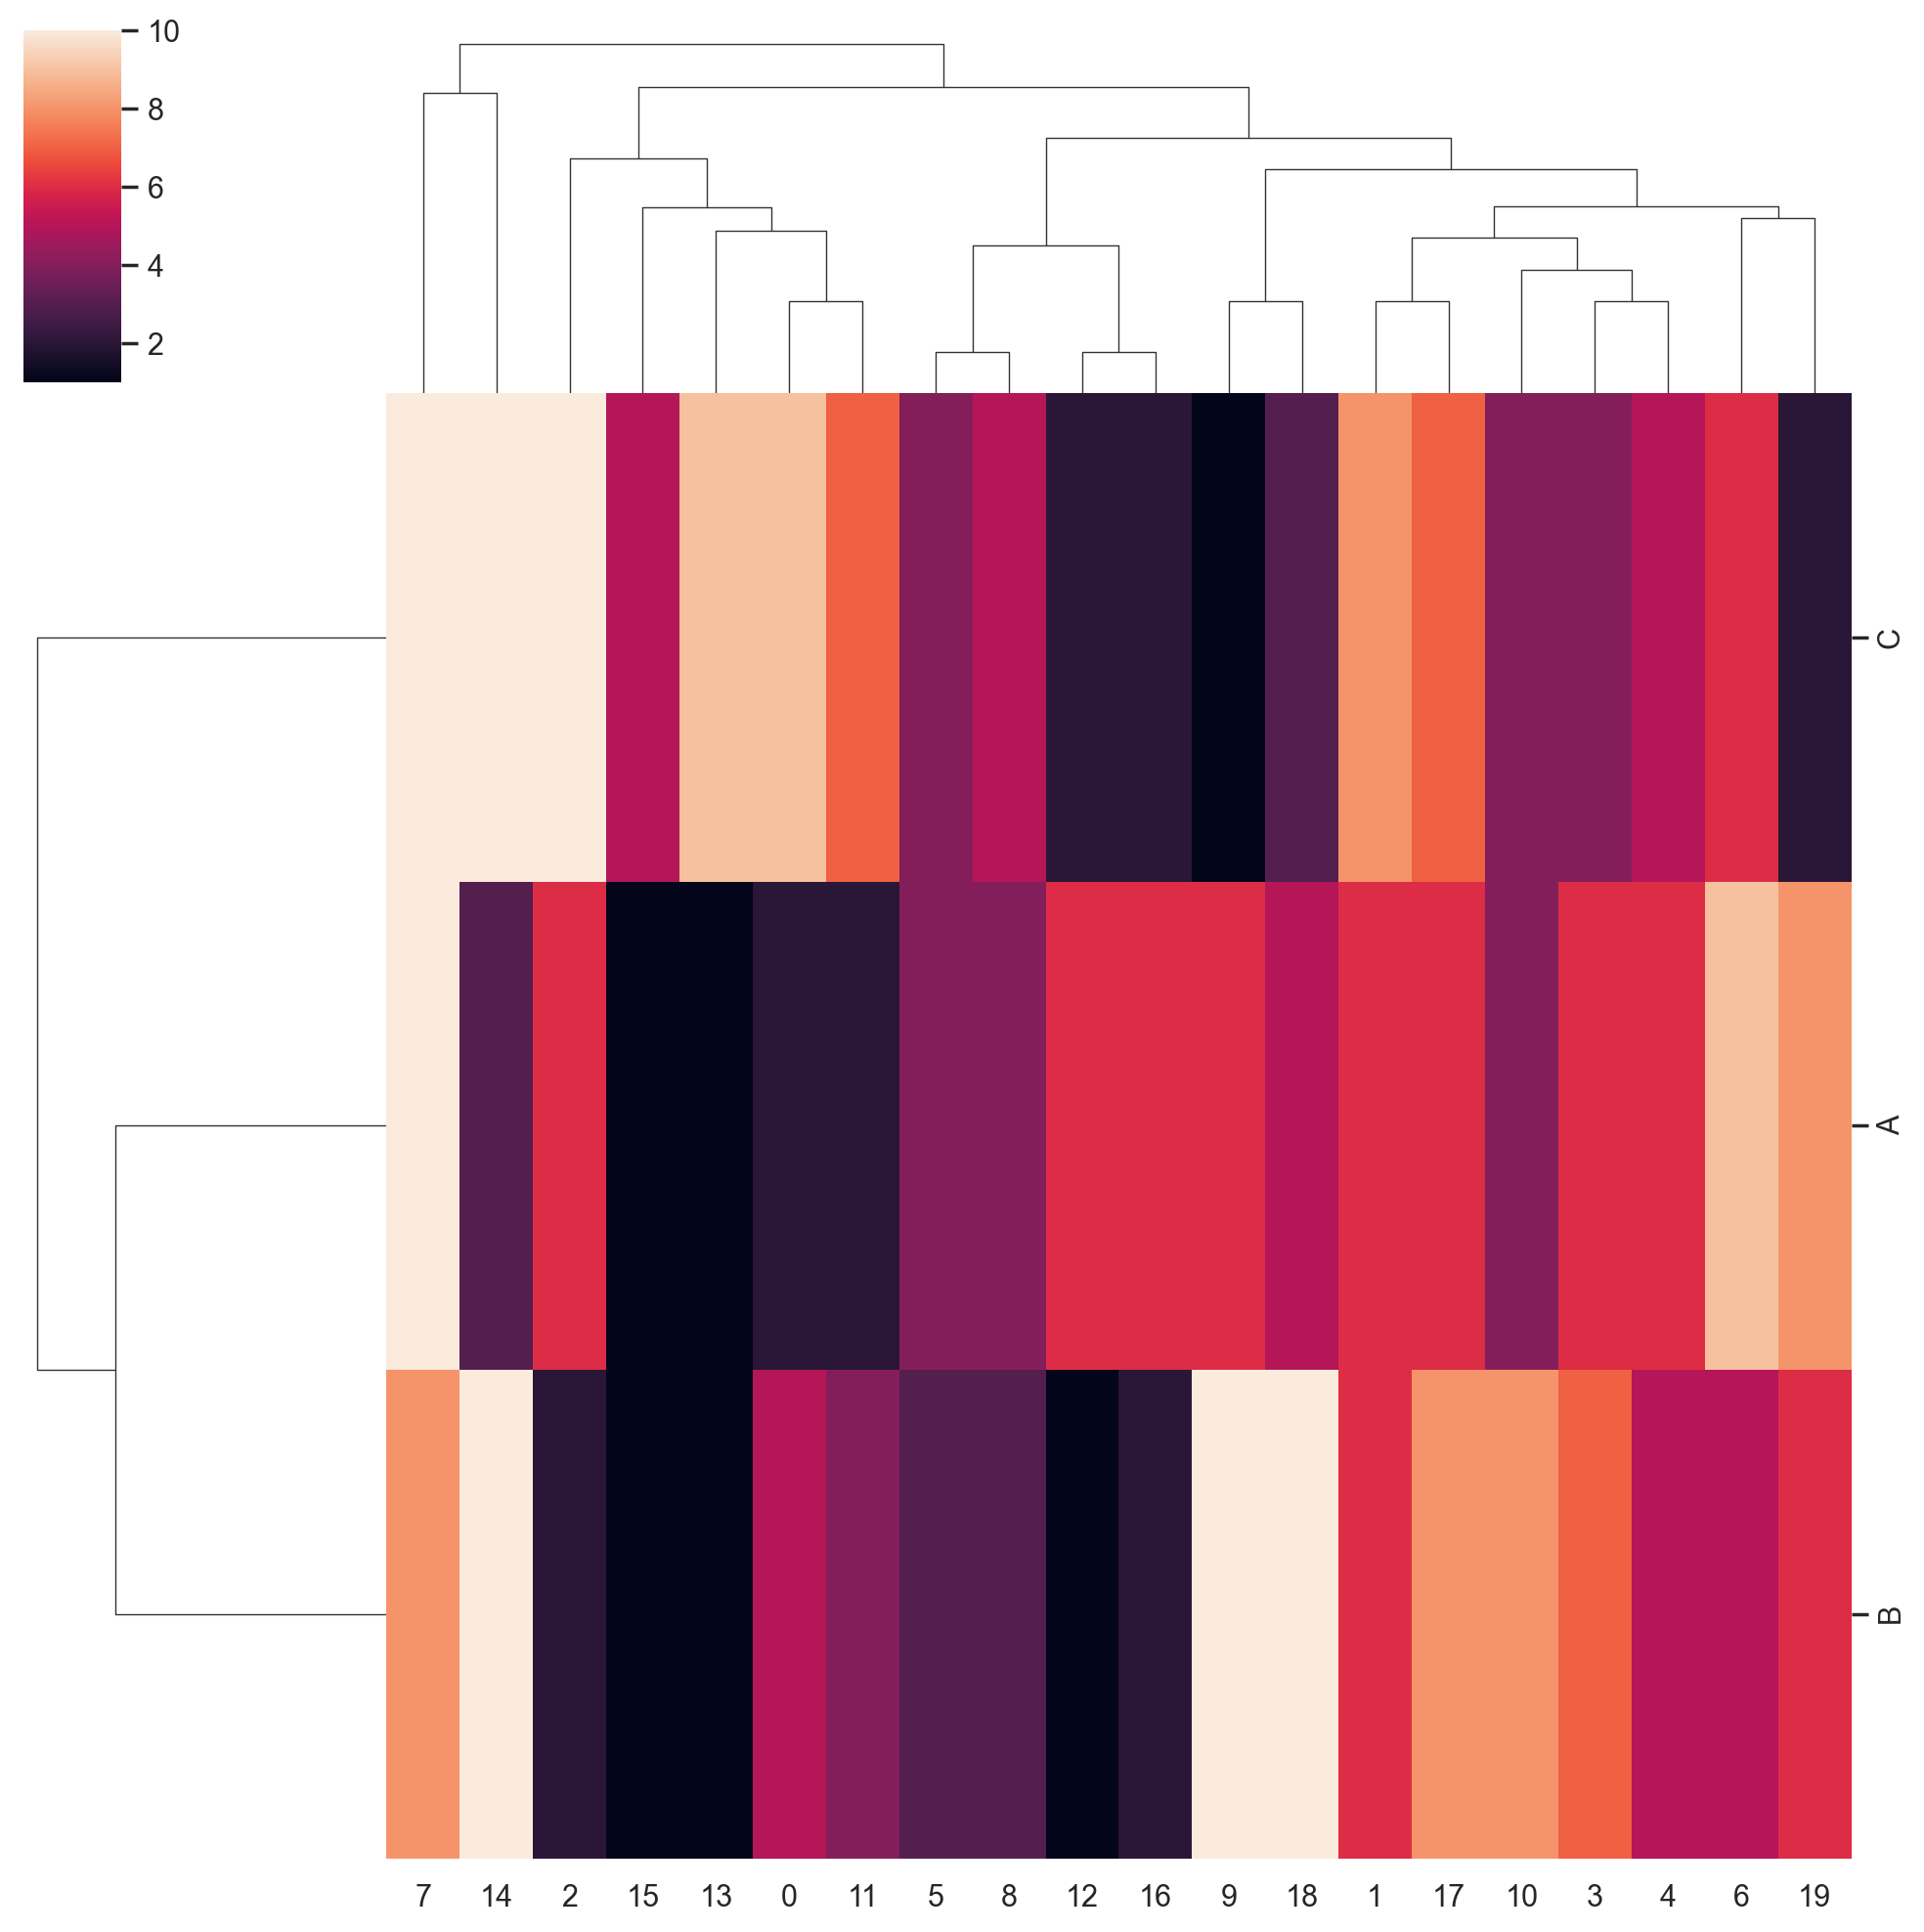

In [209]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import fcluster
from scipy.cluster.hierarchy import dendrogram
from matplotlib.colors import ListedColormap
import random

# 假设你的DataFrame是df
df = pd.DataFrame({
    'A': [random.randint(1, 10) for _ in range(20)], # 生成一个包含20个随机整数的列表，整数的范围是1到20
    'B': [random.randint(1, 10) for _ in range(20)], # 生成一个包含20个随机整数的列表，整数的范围是1到20
    'C': [random.randint(1, 10) for _ in range(20)]  # 生成一个包含20个随机整数的列表，整数的范围是1到20
}).T

# 生成聚类热图
g = sns.clustermap(df)

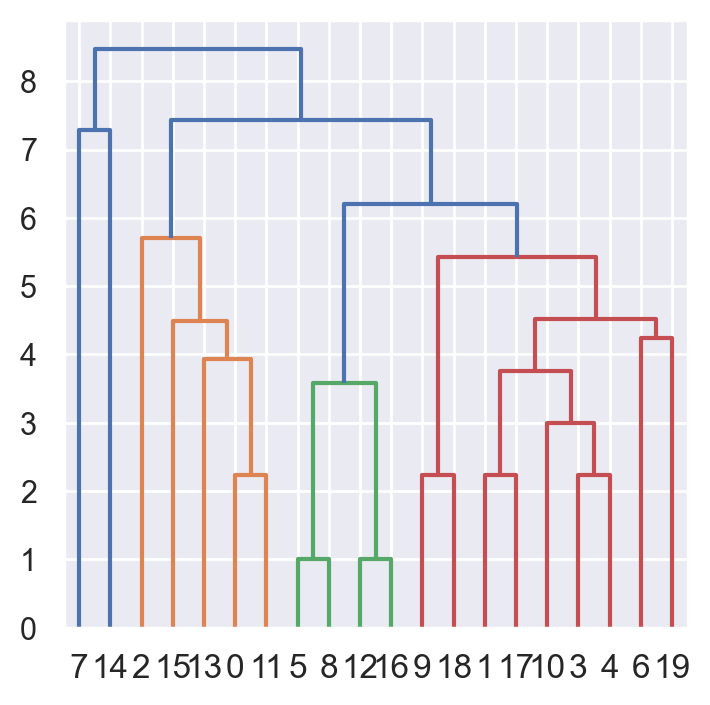

In [212]:
# 获取col聚类结果
col_linkage = g.dendrogram_col.linkage

plot2 = dendrogram(col_linkage)

In [215]:
dendrogram_df = pd.concat([pd.DataFrame({"links_color_list":plot2["color_list"]}),
                           pd.DataFrame({"leaves":plot2["leaves"]}),
                           pd.DataFrame({"leaves_label":plot2["ivl"]}),
                           pd.DataFrame({"leaves_color_list":plot2["leaves_color_list"]})],axis=1)
dendrogram_df

,links_color_list,leaves,leaves_label,leaves_color_list
0,C0,7,7,C0
1,C1,14,14,C0
2,C1,2,2,C1
3,C1,15,15,C1
4,C1,13,13,C1
5,C2,0,0,C1
6,C2,11,11,C1
7,C2,5,5,C2
8,C3,8,8,C2
9,C3,12,12,C2


In [243]:
import numpy as np
from scipy.cluster import hierarchy
import matplotlib.pyplot as plt

ytdist = np.array([662., 877., 255., 412., 996., 295., 468., 268.,
                   400., 754., 564., 138., 219., 869., 669.])
Z = hierarchy.linkage(ytdist, 'single')
Z

array([[  2.,   5., 138.,   2.],
       [  3.,   4., 219.,   2.],
       [  0.,   7., 255.,   3.],
       [  1.,   8., 268.,   4.],
       [  6.,   9., 295.,   6.]])

{'icoord': [[5.0, 5.0, 15.0, 15.0],
  [45.0, 45.0, 55.0, 55.0],
  [35.0, 35.0, 50.0, 50.0],
  [25.0, 25.0, 42.5, 42.5],
  [10.0, 10.0, 33.75, 33.75]],
 'dcoord': [[0.0, 138.0, 138.0, 0.0],
  [0.0, 219.0, 219.0, 0.0],
  [0.0, 255.0, 255.0, 219.0],
  [0.0, 268.0, 268.0, 255.0],
  [138.0, 295.0, 295.0, 268.0]],
 'ivl': ['2', '5', '1', '0', '3', '4'],
 'leaves': [2, 5, 1, 0, 3, 4],
 'color_list': ['C1', 'C0', 'C0', 'C0', 'C0'],
 'leaves_color_list': ['C1', 'C1', 'C0', 'C0', 'C0', 'C0']}

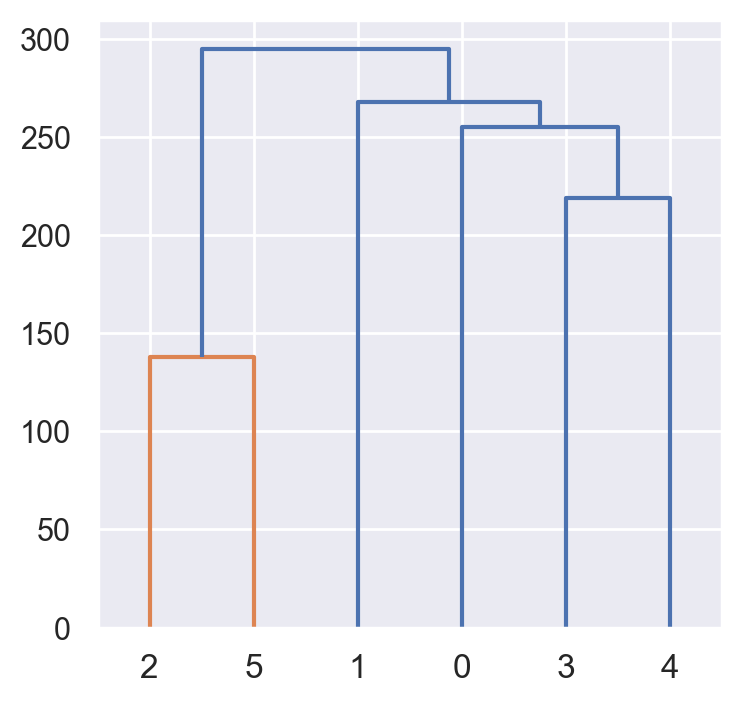

In [244]:
plt.figure()
dn = hierarchy.dendrogram(Z)
dn

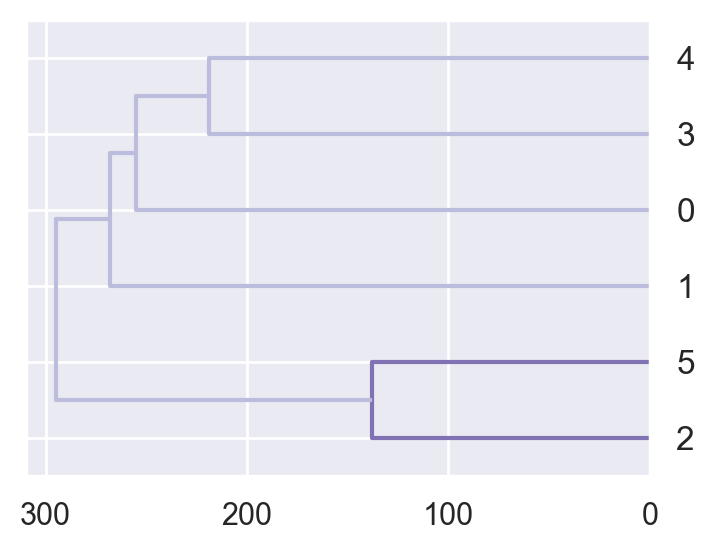

In [241]:
hierarchy.set_link_color_palette(['m', 'c', 'y', 'k'])
fig, axes = plt.subplots(1, figsize=(4, 3))
#dn1 = hierarchy.dendrogram(Z, ax=axes[0], 
#                           above_threshold_color='y',
#                           orientation='top')
dn2 = hierarchy.dendrogram(Z, ax=axes,
                           above_threshold_color='#bcbddc',
                           orientation='left')
hierarchy.set_link_color_palette(None)  # reset to default after use
plt.show()

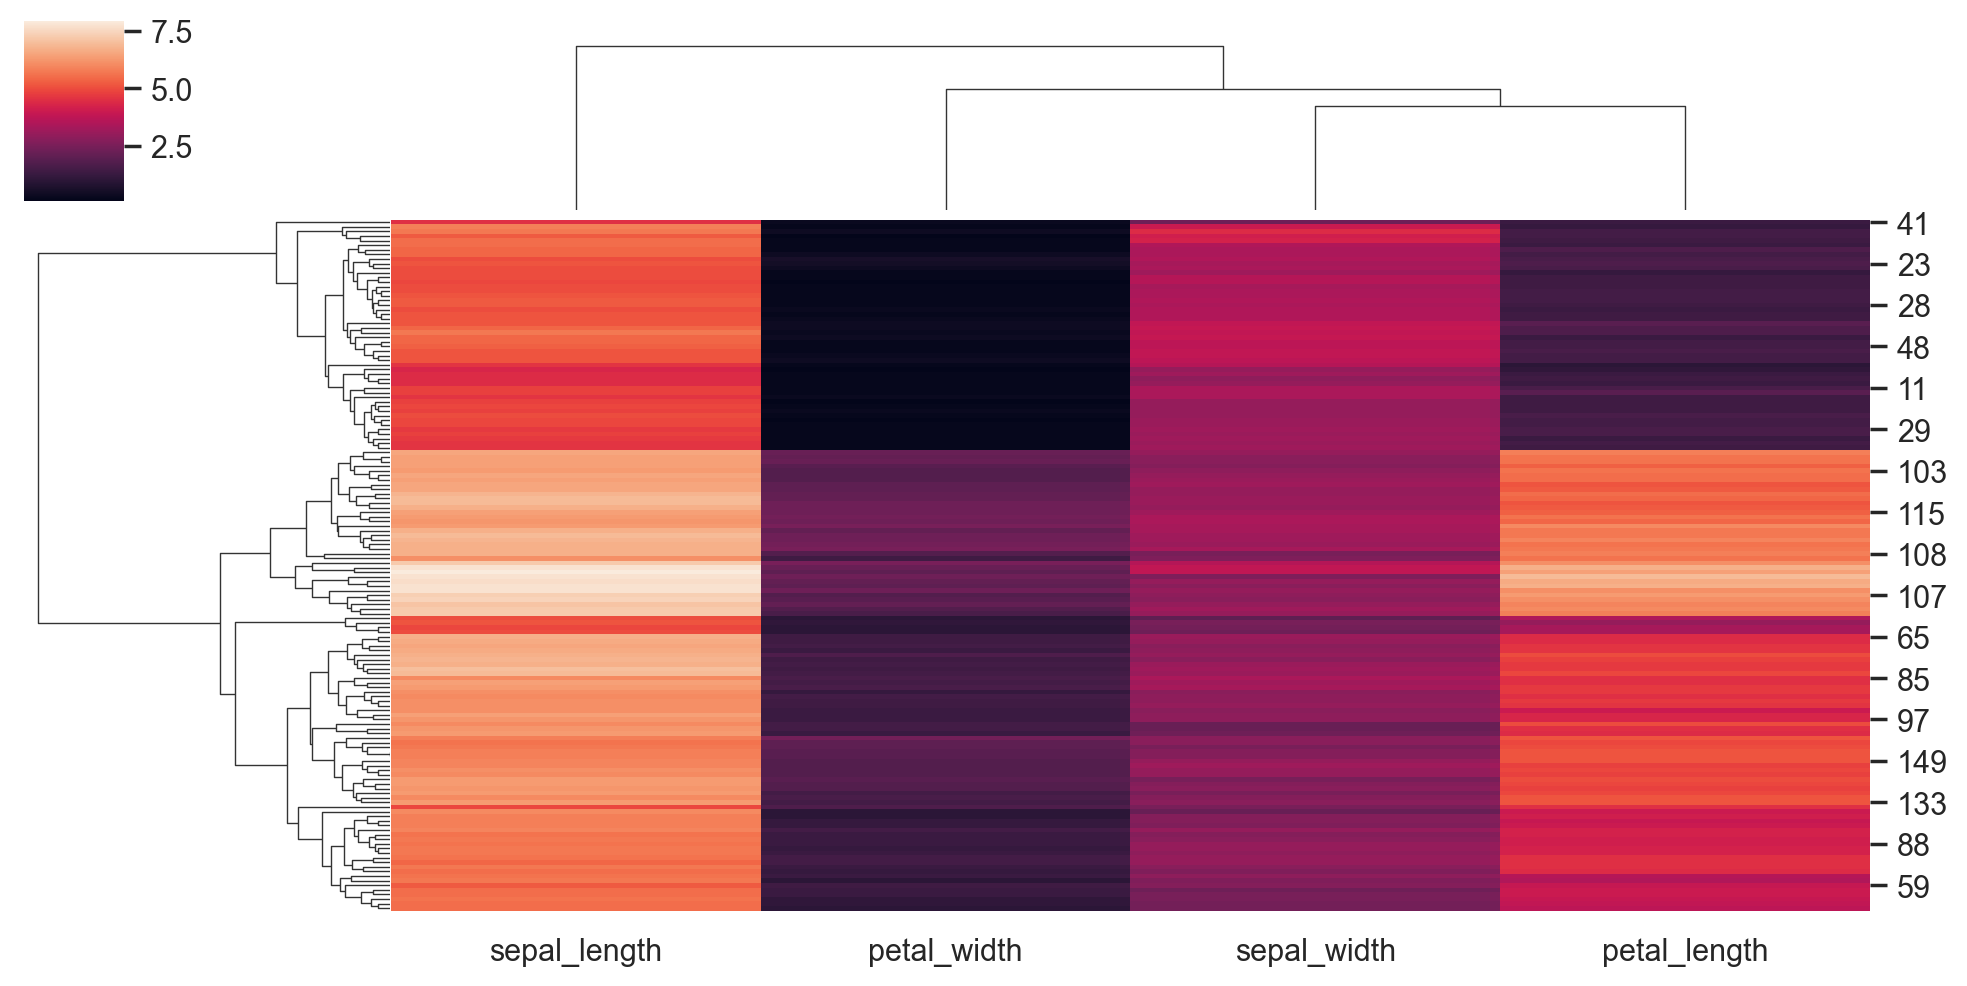

In [225]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set(color_codes=True)
import pandas as pd


iris = sns.load_dataset("iris")
species = iris.pop("species")

# 创建图形
#fig = plt.subplots(figsize=(13,10),dpi=100,facecolor="w")
g = sns.clustermap(iris,figsize=(10, 5))


In [230]:
g.dendrogram_row

AttributeError: 'dict' object has no attribute 'grid'

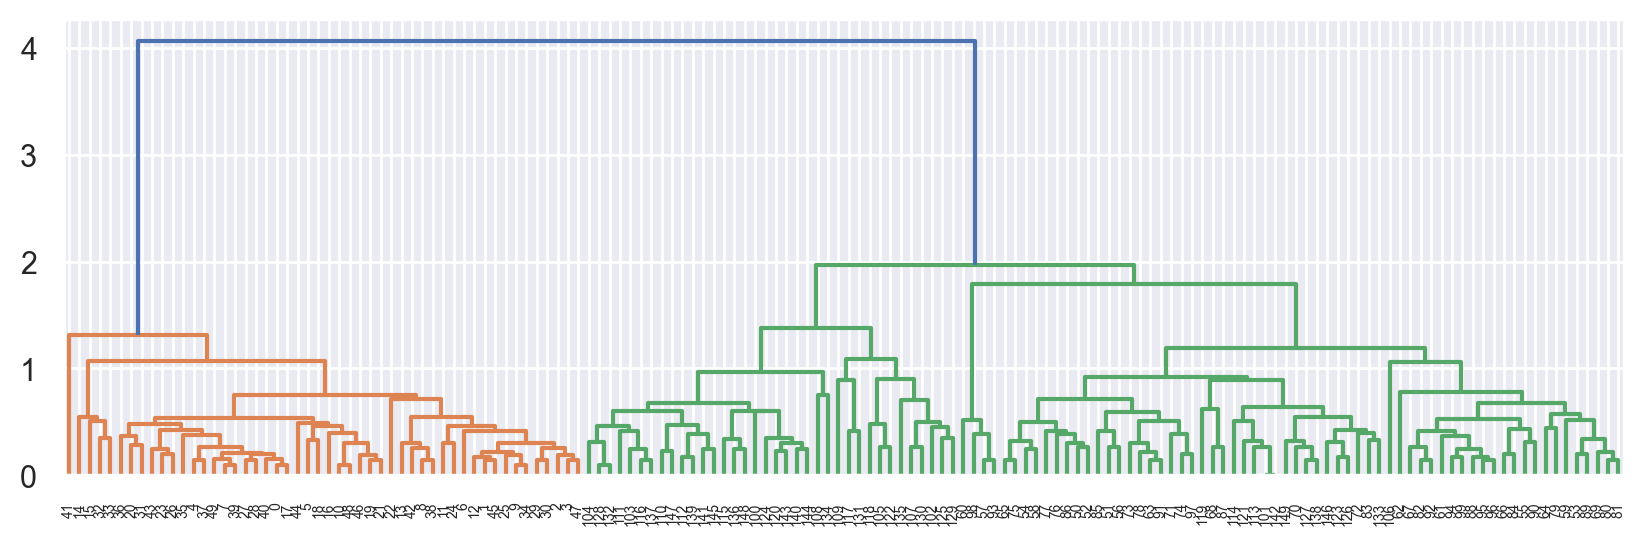

In [226]:
# 获取col聚类结果
col_linkage = g.dendrogram_col.linkage
row_linkage = g.dendrogram_row.linkage

# 创建图形
fig,ax = plt.subplots(figsize=(10,3),dpi=100,facecolor="w")
#plot1 = dendrogram(col_linkage)
ax = dendrogram(row_linkage)
ax.grid(False)  # 关闭网格线

In [ ]:
dendrogram_df = pd.concat([pd.DataFrame({"ivl":plot2["ivl"]}),
                           pd.DataFrame({"color_list":plot2["color_list"]}),
                           pd.DataFrame({"leaves":plot2["leaves"]}),
                           pd.DataFrame({"leaves_color_list":plot2["leaves_color_list"]})],axis=1)
dendrogram_df

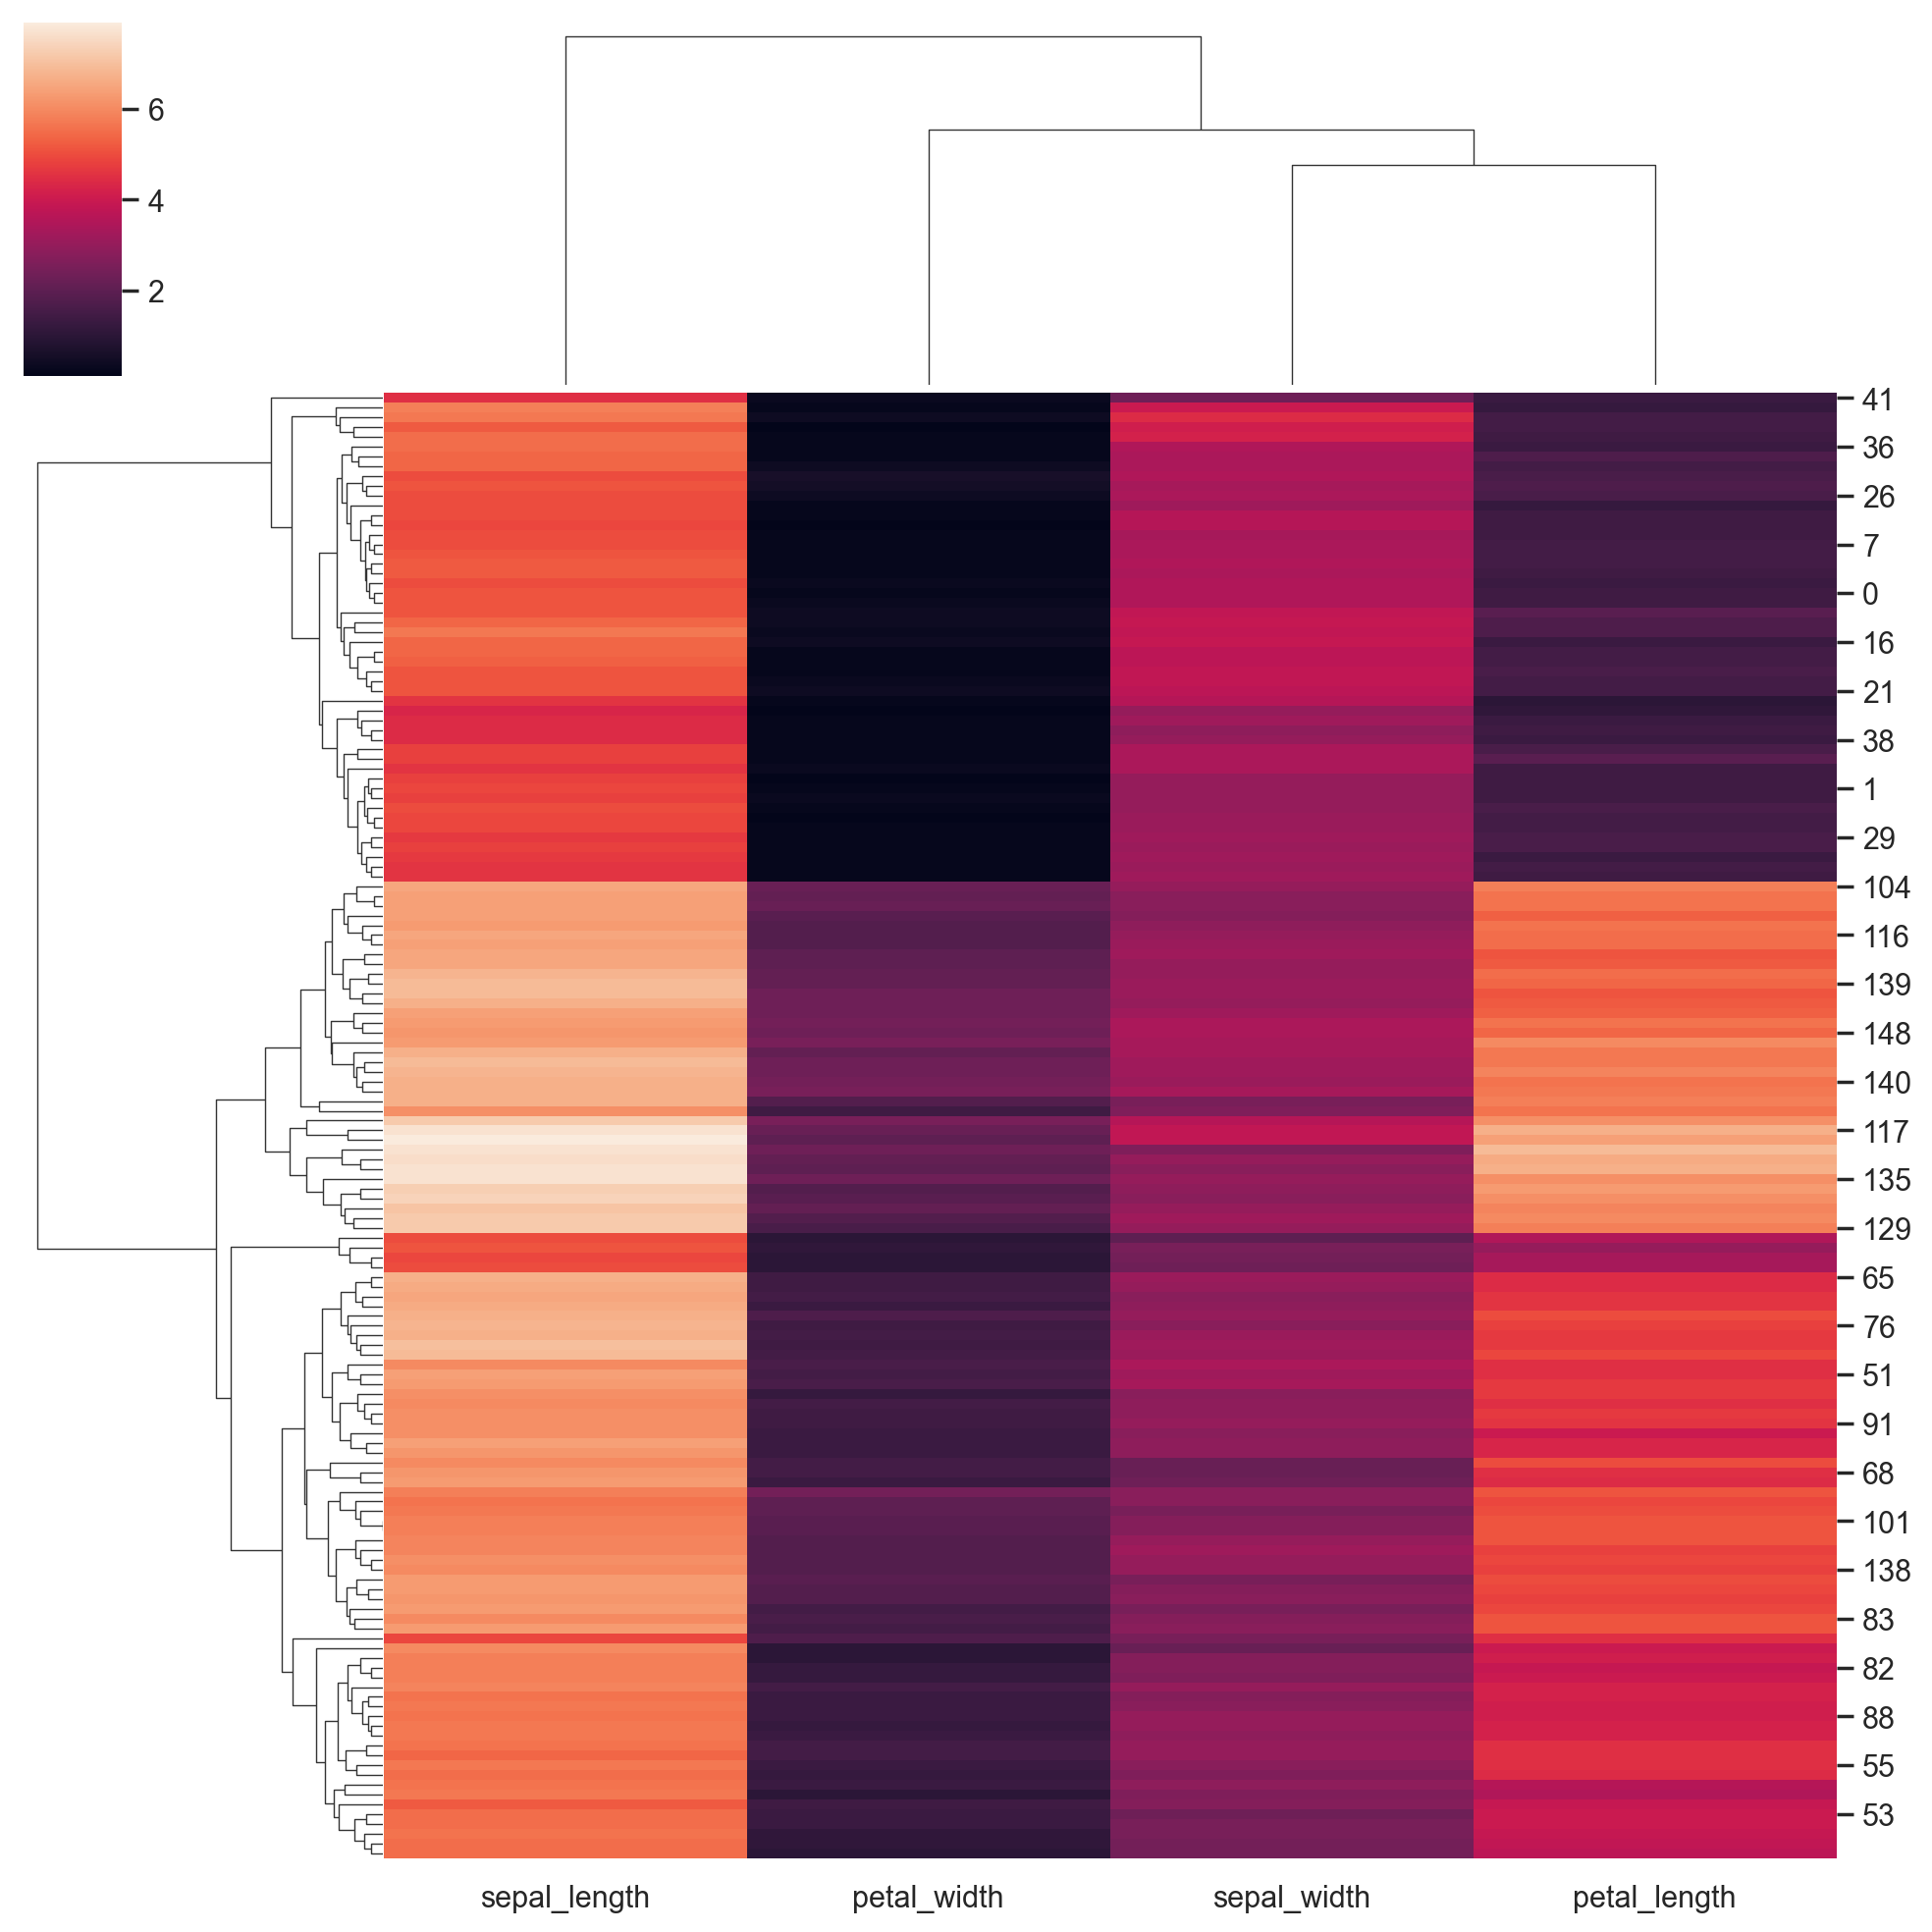

In [158]:
iris = sns.load_dataset("iris")
species = iris.pop("species")
g = sns.clustermap(iris)

In [163]:
type(iris)

pandas.core.frame.DataFrame

In [160]:
species.value_counts()

setosa        50
versicolor    50
virginica     50
Name: species, dtype: int64

In [161]:
lut

{'setosa': 'r', 'versicolor': 'b', 'virginica': 'g'}

In [167]:
df_colors

,r,g,b
0,r,NaN,NaN
1,r,NaN,NaN
2,r,NaN,NaN
3,r,NaN,NaN
4,r,NaN,NaN
...,...,...,...
145,NaN,g,NaN
146,NaN,g,NaN
147,NaN,g,NaN
148,NaN,g,NaN


In [170]:
{'colors':[colmap[s] for s in species]}

{'colors': [(1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (1, 0, 0, 0.7),
  (0, 0, 1, 0.7),
  (0, 0, 1, 0.7),
  (0, 0, 1, 0.7),
  (0, 0, 1, 0.7),
  (0, 0, 1, 0.7),


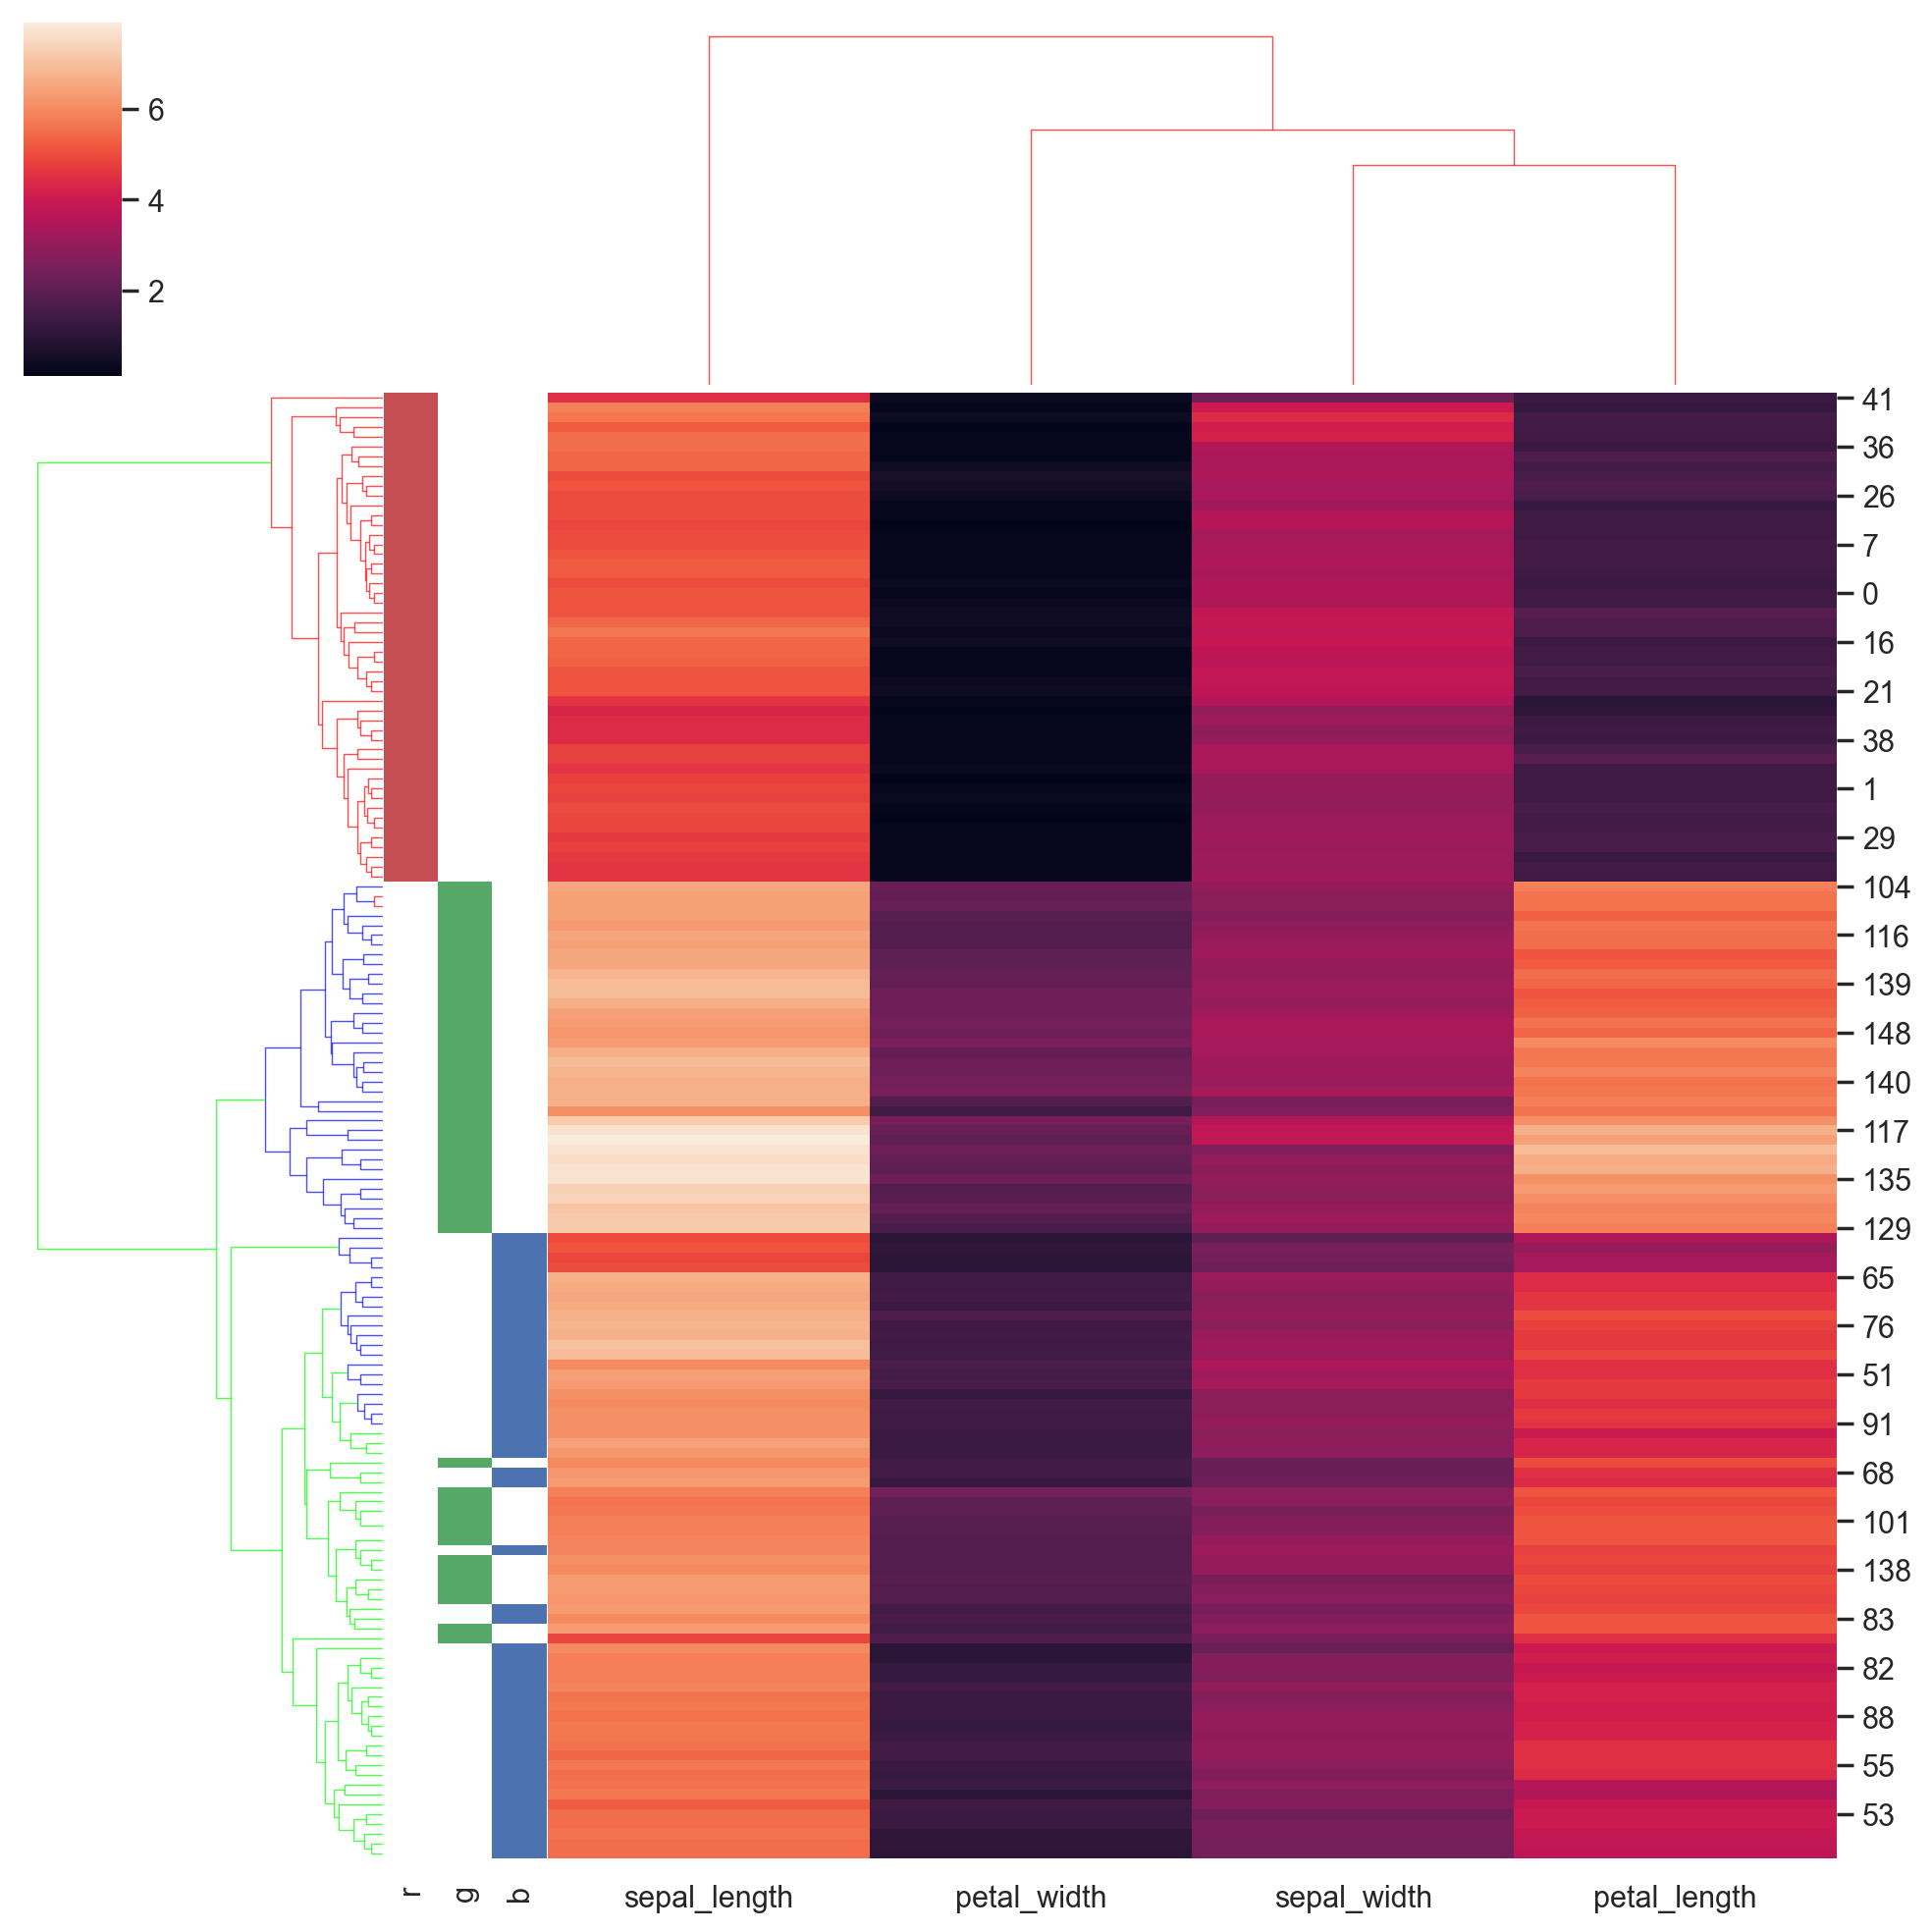

In [147]:
lut = dict(zip(species.unique(), "rbg"))
row_colors = species.map(lut)
# For demonstrating the hierarchical sidebar coloring
df_colors = pd.DataFrame(data={'r': row_colors[row_colors == 'r'], 'g': row_colors[row_colors == 'g'], 'b': row_colors[row_colors == 'b']}) 
# Simple class RGBA colormap
colmap = {'setosa': (1, 0, 0, 0.7), 'virginica': (0, 1, 0, 0.7), 'versicolor': (0, 0, 1, 0.7)}

g = sns.clustermap(iris, row_colors=df_colors, tree_kws={'colors':[colmap[s] for s in species]})
#plt.savefig('clustermap.png')

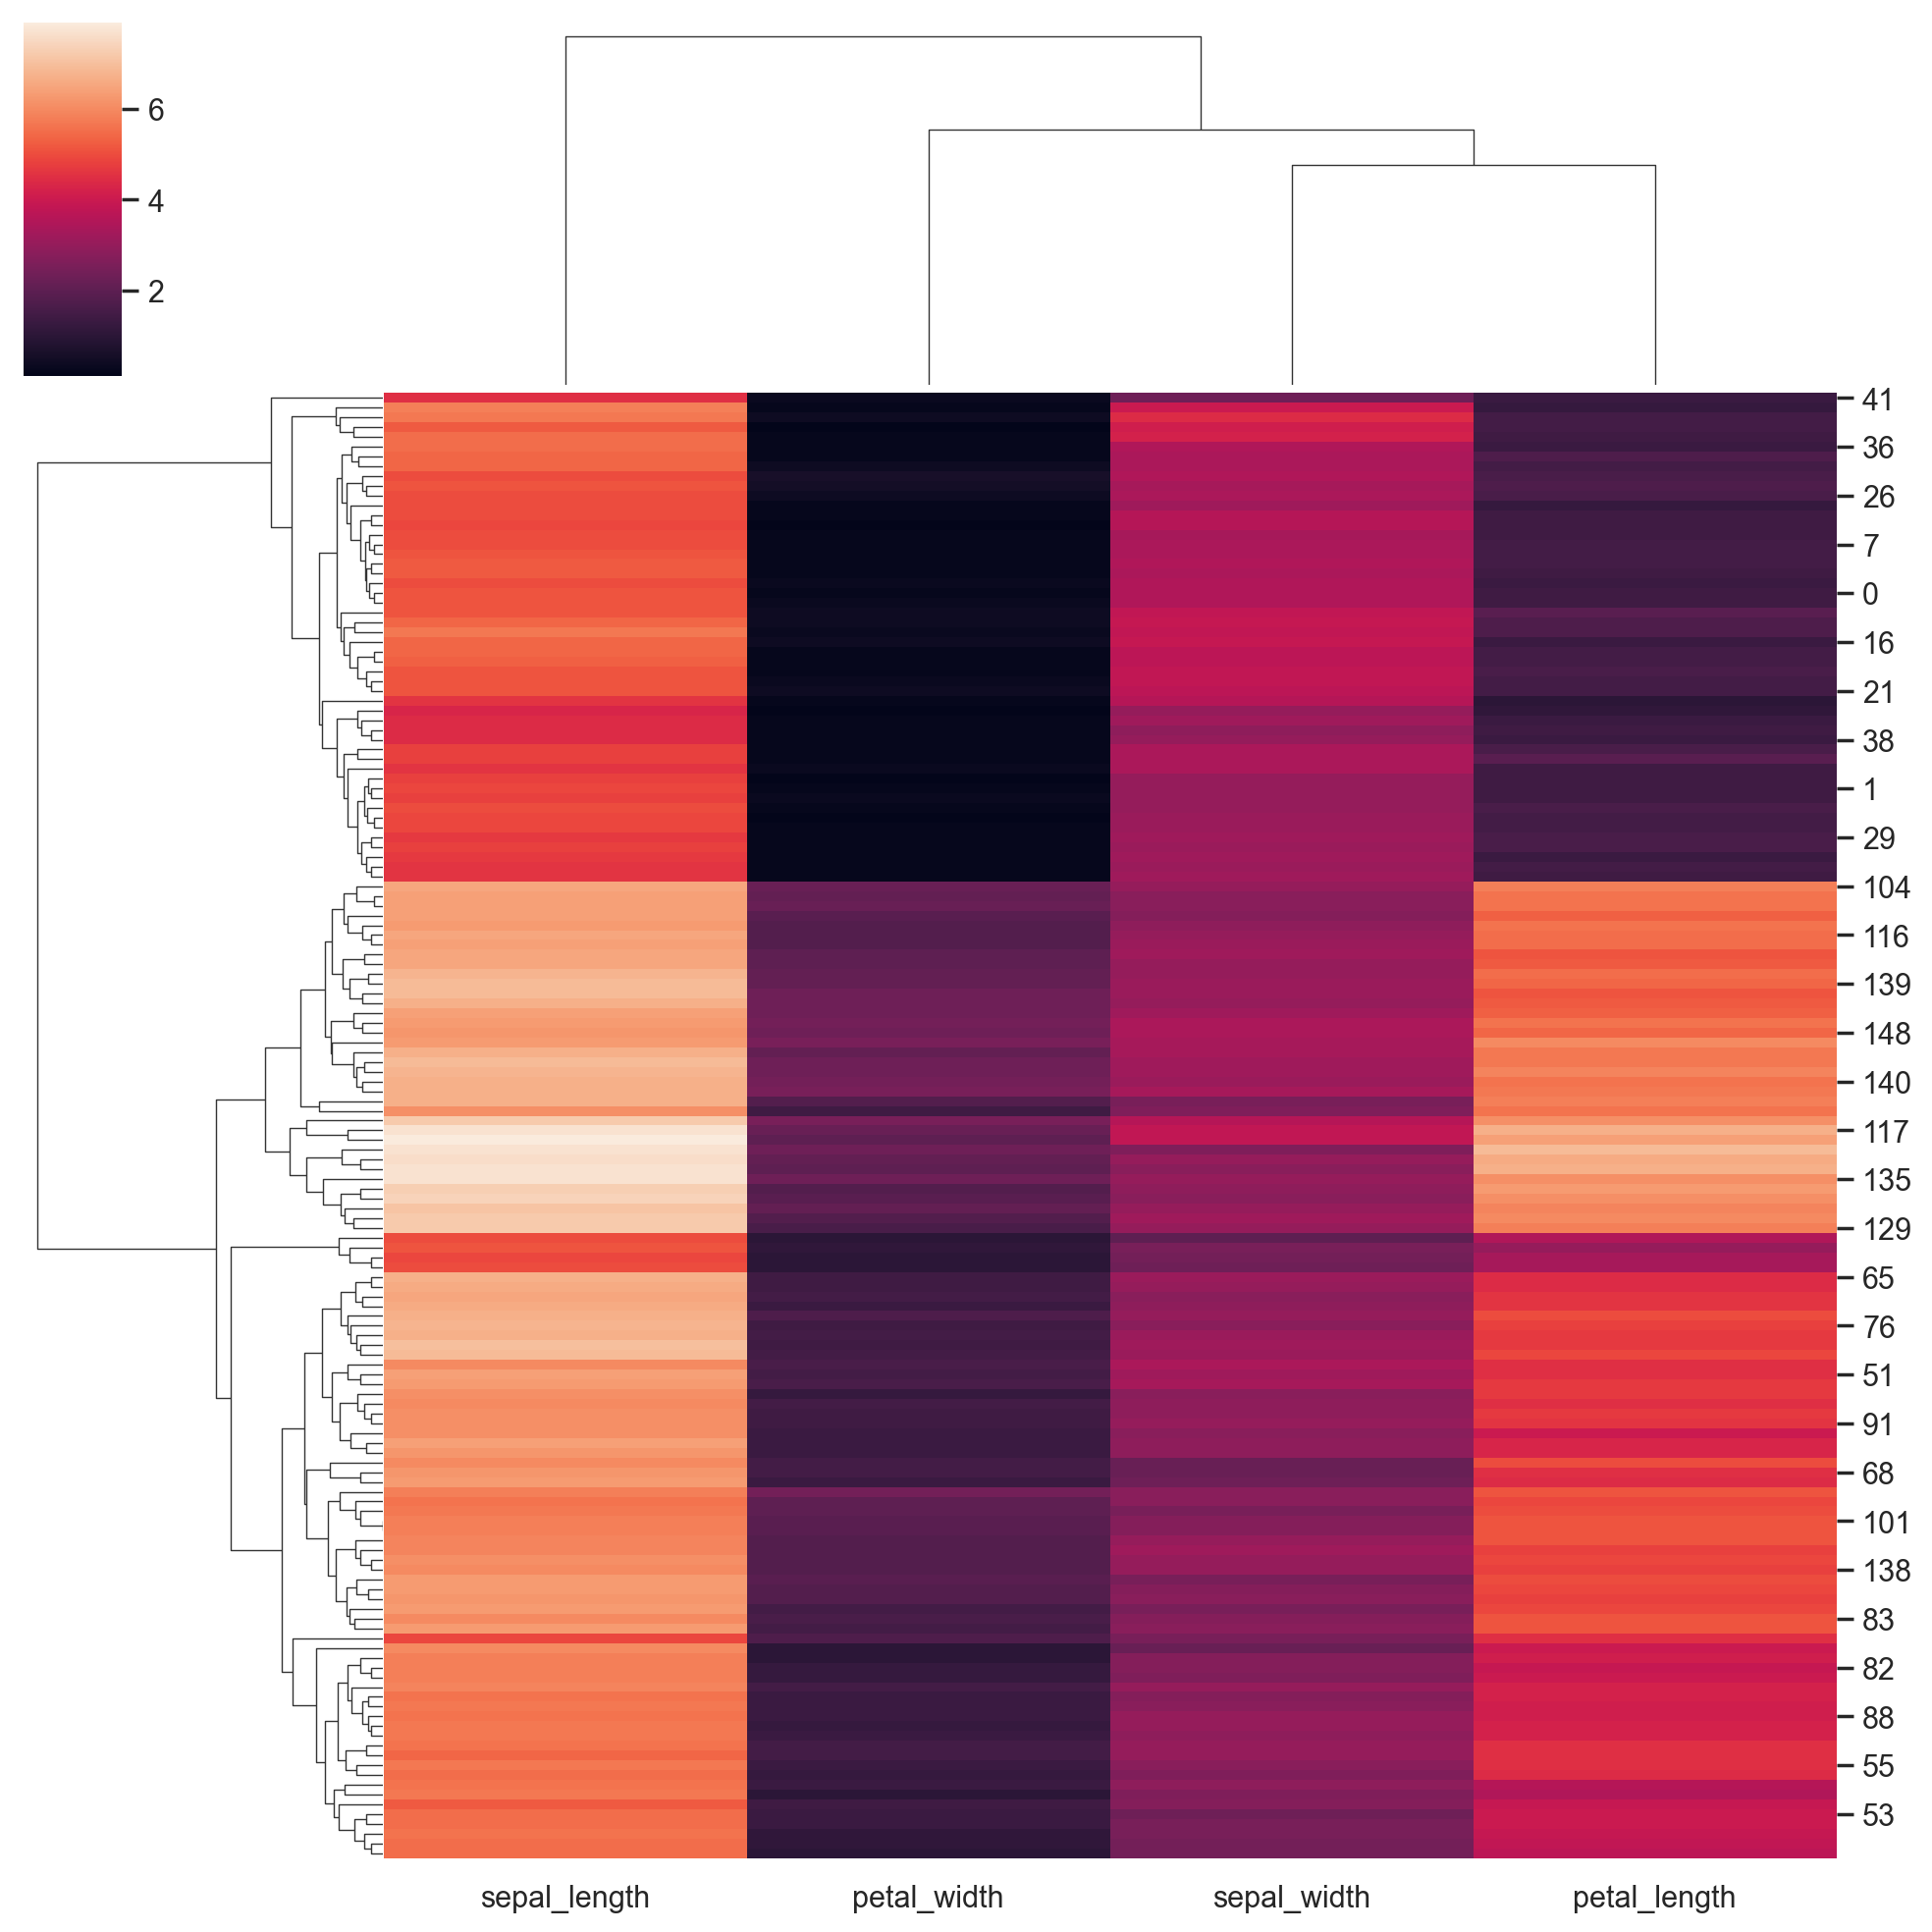

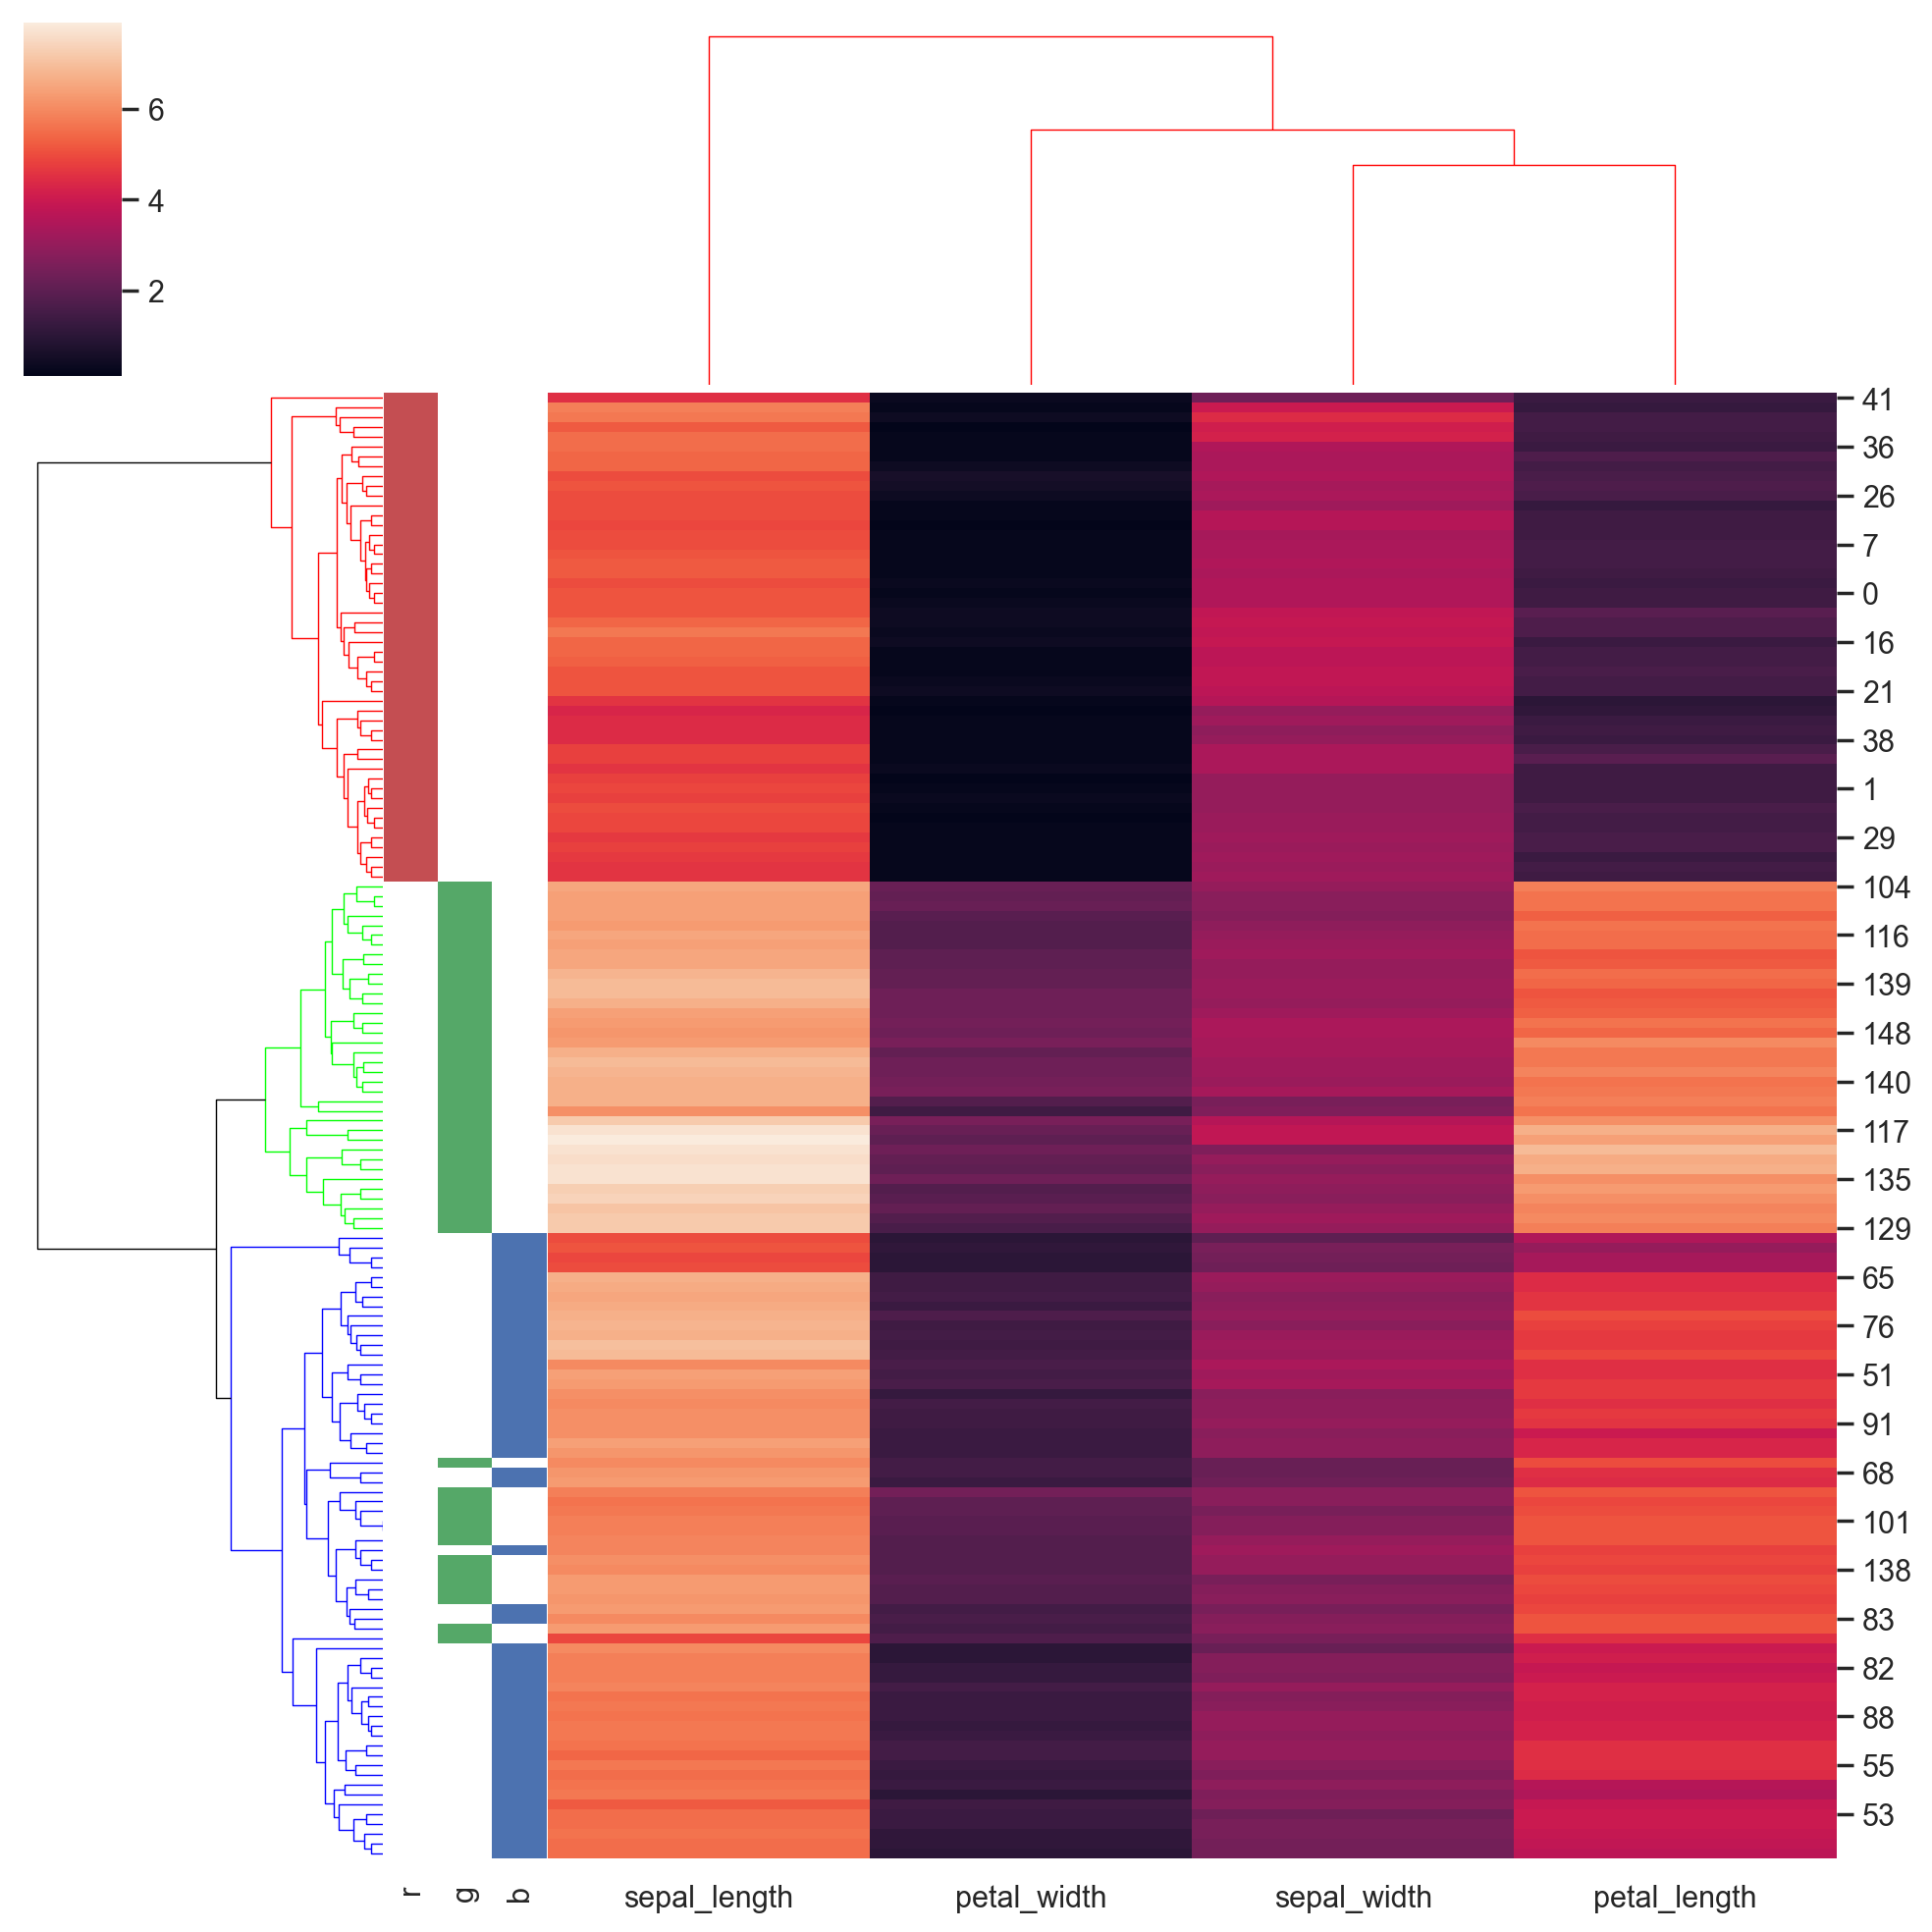

In [148]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set(color_codes=True)
import pandas as pd


#iris = sns.load_dataset("iris")
#species = iris.pop("species")
g = sns.clustermap(iris)
lut = dict(zip(species.unique(), "rbg"))
row_colors = species.map(lut)
# For demonstrating the hierarchical sidebar coloring
df_colors = pd.DataFrame(data={'r': row_colors[row_colors == 'r'], 'g': row_colors[row_colors == 'g'], 'b': row_colors[row_colors == 'b']}) 
# Simple class RGBA colormap
colmap = {'setosa': (1, 0, 0, 0.7), 'virginica': (0, 1, 0, 0.7), 'versicolor': (0, 0, 1, 0.7)}
g = sns.clustermap(iris, row_colors=df_colors, tree_kws={'colors':[(1,0,0,1)]*49+[(0,1,0,1)]*35+[(0,0,1,1)]*63+[(0,0,0,1)]*2})
#plt.savefig('clustermap.png')